In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/Users/hrchapmandutton/Documents/Projects/CDW/all_fires_2001_2019_clip_single_burn_w_regions.csv')
df.columns

Index(['FID', 'NAME', 'RECORDNUMB', 'ACRES', 'PERIMETERD', 'SOURCE',
       'SOURCEMETH', 'SOURCECLAS', 'AGENCYACRE', 'COMMENTS', 'FIREID',
       'FIREYEAR', 'UPDATETIME', 'FPOUTDATE', 'IRWINID', 'PRESCRIBED',
       'FIRESEASON', 'UniqueID', 'area_sqkm', 'SRC_AGENCY', 'NAT_PARK',
       'MONTH', 'DAY', 'REP_DATE', 'DATE_TYPE', 'DECADE', 'SIZE_HA', 'CALC_HA',
       'SOURCE_KEY', 'MORE_INFO', 'CFS_REF_ID', 'count', 'per_single',
       'Shape_Leng', 'Unique_ID', 'eco_full', 'ctry_full', 'sin_sqkm',
       'Shape_Le_1', 'Shape_Area', 'eco', 'ctry', 'GHG', 'Permafrost',
       'Albedo', 'Recovery', 'NetRF', 'PermProb', 'PermCat', 'ClimateCat',
       'MaxsAreaKm', 'PerMaxData', 'MaxData', 'FrClpAreKm'],
      dtype='object')

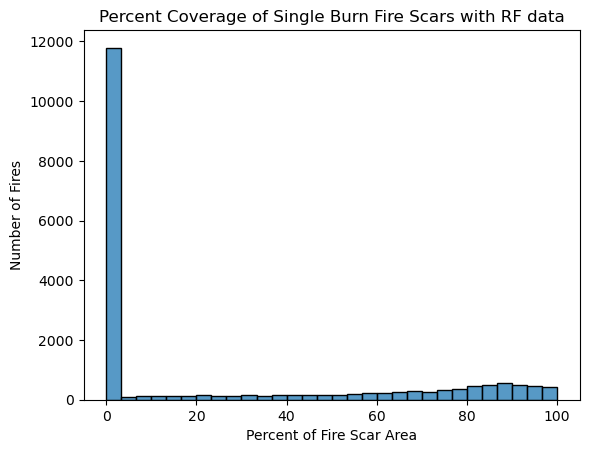

In [4]:
plt.figure()
ax = sns.histplot(data=df, x='PerMaxData', bins=30)
ax.set_title('Percent Coverage of Single Burn Fire Scars with RF data')
ax.set_ylabel('Number of Fires')
ax.set_xlabel('Percent of Fire Scar Area')
plt.show()

In [7]:
df_filter = df[df['MaxData'] == 1]
print(len(df_filter))

7230
18892


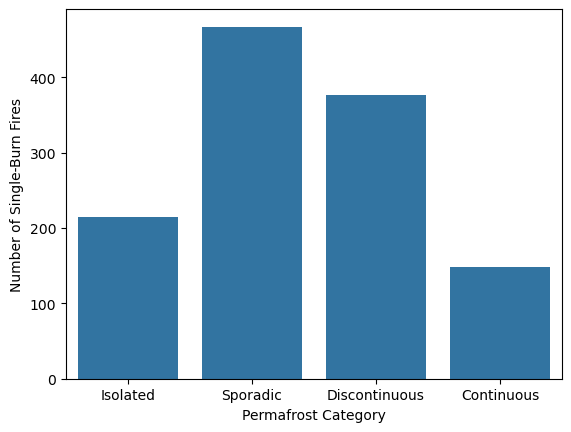

In [8]:
df_perm = df_filter[(df_filter['PermCat'] != ' ') & (df_filter['ctry'] == 'Alaska')]
plt.figure()
ax = sns.countplot(data = df_perm, x = 'PermCat', order=['Isolated', 'Sporadic', 'Discontinuous', 'Continuous'])
ax.set_ylabel('Number of Single-Burn Fires')
ax.set_xlabel('Permafrost Category')
plt.show()

In [9]:
df_filter = df.loc[df['MaxData'] == 1].copy()

rep_dates = pd.to_datetime(df_filter["REP_DATE"], errors="coerce")
fpout_dates = pd.to_datetime(df_filter["FPOUTDATE"], errors="coerce")
best_dates = rep_dates.fillna(fpout_dates)
existing_month = pd.to_numeric(df_filter["MONTH"], errors="coerce")
existing_day = pd.to_numeric(df_filter["DAY"], errors="coerce")

# Treat 0 as missing in the original month/day fields.
existing_month = existing_month.replace(0, pd.NA)
existing_day = existing_day.replace(0, pd.NA)

df_filter["MONTH"] = pd.to_numeric(best_dates.dt.month.fillna(existing_month), errors="coerce")
df_filter["DAY"] = pd.to_numeric(best_dates.dt.day.fillna(existing_day), errors="coerce")
df_filter["MONTH"] = df_filter["MONTH"].replace(0, pd.NA)
df_filter["DAY"] = df_filter["DAY"].replace(0, pd.NA)

print(df_filter["MONTH"].unique())

[ 9. 10.  8. 12. 11.  6.  7.  5. nan  4.  3.  2.  1.]


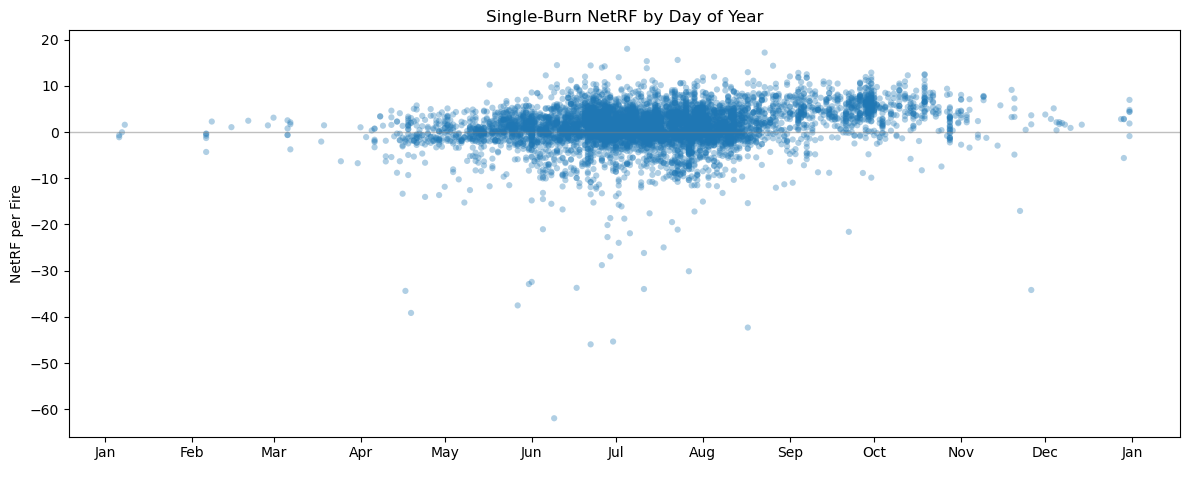

In [45]:
# Plot every fire by calendar day (month + day), combining all years.
import matplotlib.dates as mdates

plot_df = df_filter.copy()

month_source = best_dates.dt.month.fillna(plot_df["MONTH"])
day_source = best_dates.dt.day.fillna(plot_df["DAY"])

plot_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

plot_df = plot_df.dropna(subset=["month_day", "NetRF"]).copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    plot_df["month_day"],
    plot_df["NetRF"],
    s=20,
    alpha=0.35,
    edgecolors="none",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

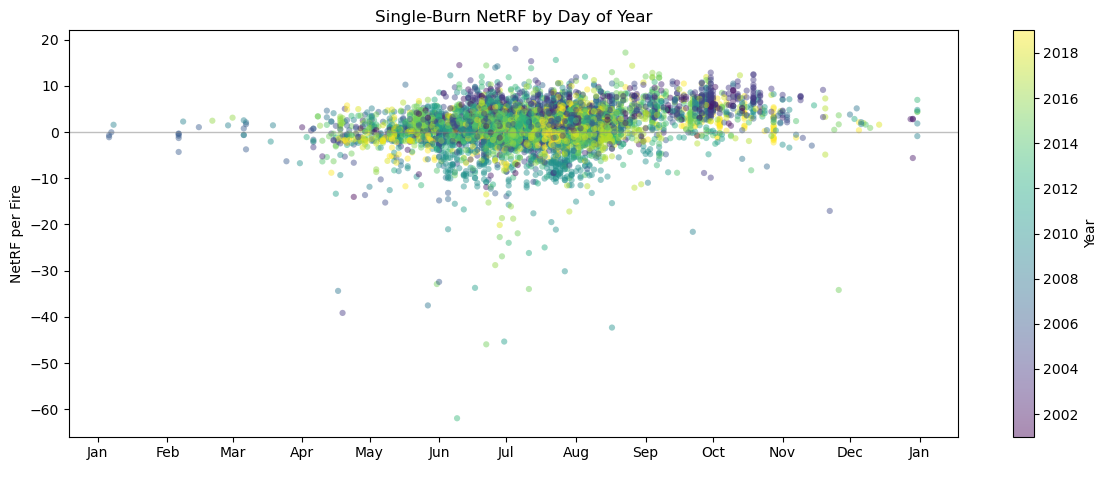

In [62]:
plot_df = df_filter.copy()

year_col = "FIREYEAR" if "FIREYEAR" in plot_df.columns else "YEAR"

plot_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

# Keep all individual fires with a constant marker size.
plot_df = plot_df.dropna(subset=["month_day", "NetRF", year_col]).copy()

fig, ax = plt.subplots(figsize=(12, 5))
scatter = ax.scatter(
    plot_df["month_day"],
    plot_df["NetRF"],
    c=plot_df[year_col],
    cmap="viridis",
    vmin=2001,
    vmax=2019,
    s=20,
    alpha=0.45,
    edgecolors="none",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Year")

ax.set_title("Single-Burn NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

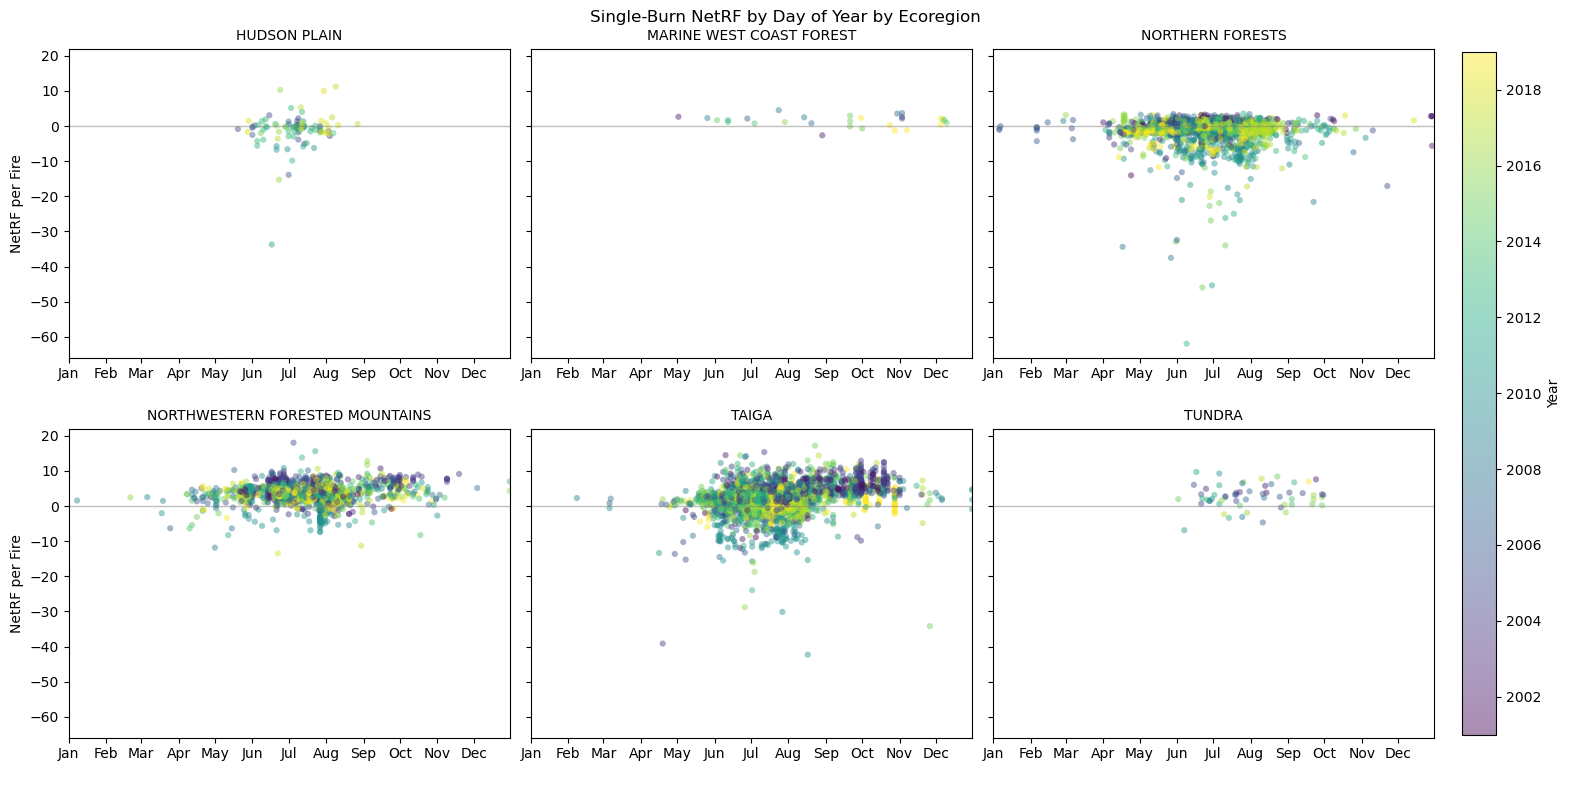

In [65]:
# Same scatter plot, faceted by ecoregion (eco).
facet_df = df_filter.copy()
facet_df = facet_df[facet_df['eco'] != 'NORTH AMERICAN DESERTS']
facet_df = facet_df[facet_df['eco'] != 'GREAT PLAINS']

year_col = "FIREYEAR" if "FIREYEAR" in facet_df.columns else "YEAR"

facet_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

facet_df = facet_df.dropna(subset=["month_day", "NetRF", year_col, "eco"]).copy()
facet_df[year_col] = pd.to_numeric(facet_df[year_col], errors="coerce")
facet_df = facet_df.dropna(subset=[year_col]).copy()

eco_order = sorted(facet_df["eco"].astype(str).unique())
n_eco = len(eco_order)
ncols = 3
nrows = int(np.ceil(n_eco / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.8 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )
axes = np.atleast_1d(axes).flatten()

x_start = pd.Timestamp("2004-01-01")
x_end = pd.Timestamp("2004-12-31")

for ax, eco_name in zip(axes, eco_order):
    sub = facet_df[facet_df["eco"] == eco_name]
    scatter = ax.scatter(
        sub["month_day"],
        sub["NetRF"],
        c=sub[year_col],
        cmap="viridis",
        vmin=2001,
        vmax=2019,
        s=20,
        alpha=0.45,
        edgecolors="none",
    )
    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.set_title(str(eco_name), fontsize=10)
    ax.set_xlim(x_start, x_end)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelbottom=True)

# Hide any unused subplot axes.
for ax in axes[n_eco:]:
    ax.set_visible(False)

# Labels on outer edges to reduce clutter.
for i, ax in enumerate(axes[:n_eco]):
    if i % ncols == 0:
        ax.set_ylabel("NetRF per Fire")
    ax.set_xlabel(" ")

cbar = fig.colorbar(scatter, ax=axes[:n_eco], fraction=0.025, pad=0.02)
cbar.set_label("Year")
fig.suptitle("Single-Burn NetRF by Day of Year by Ecoregion", y=1.02)

plt.show()

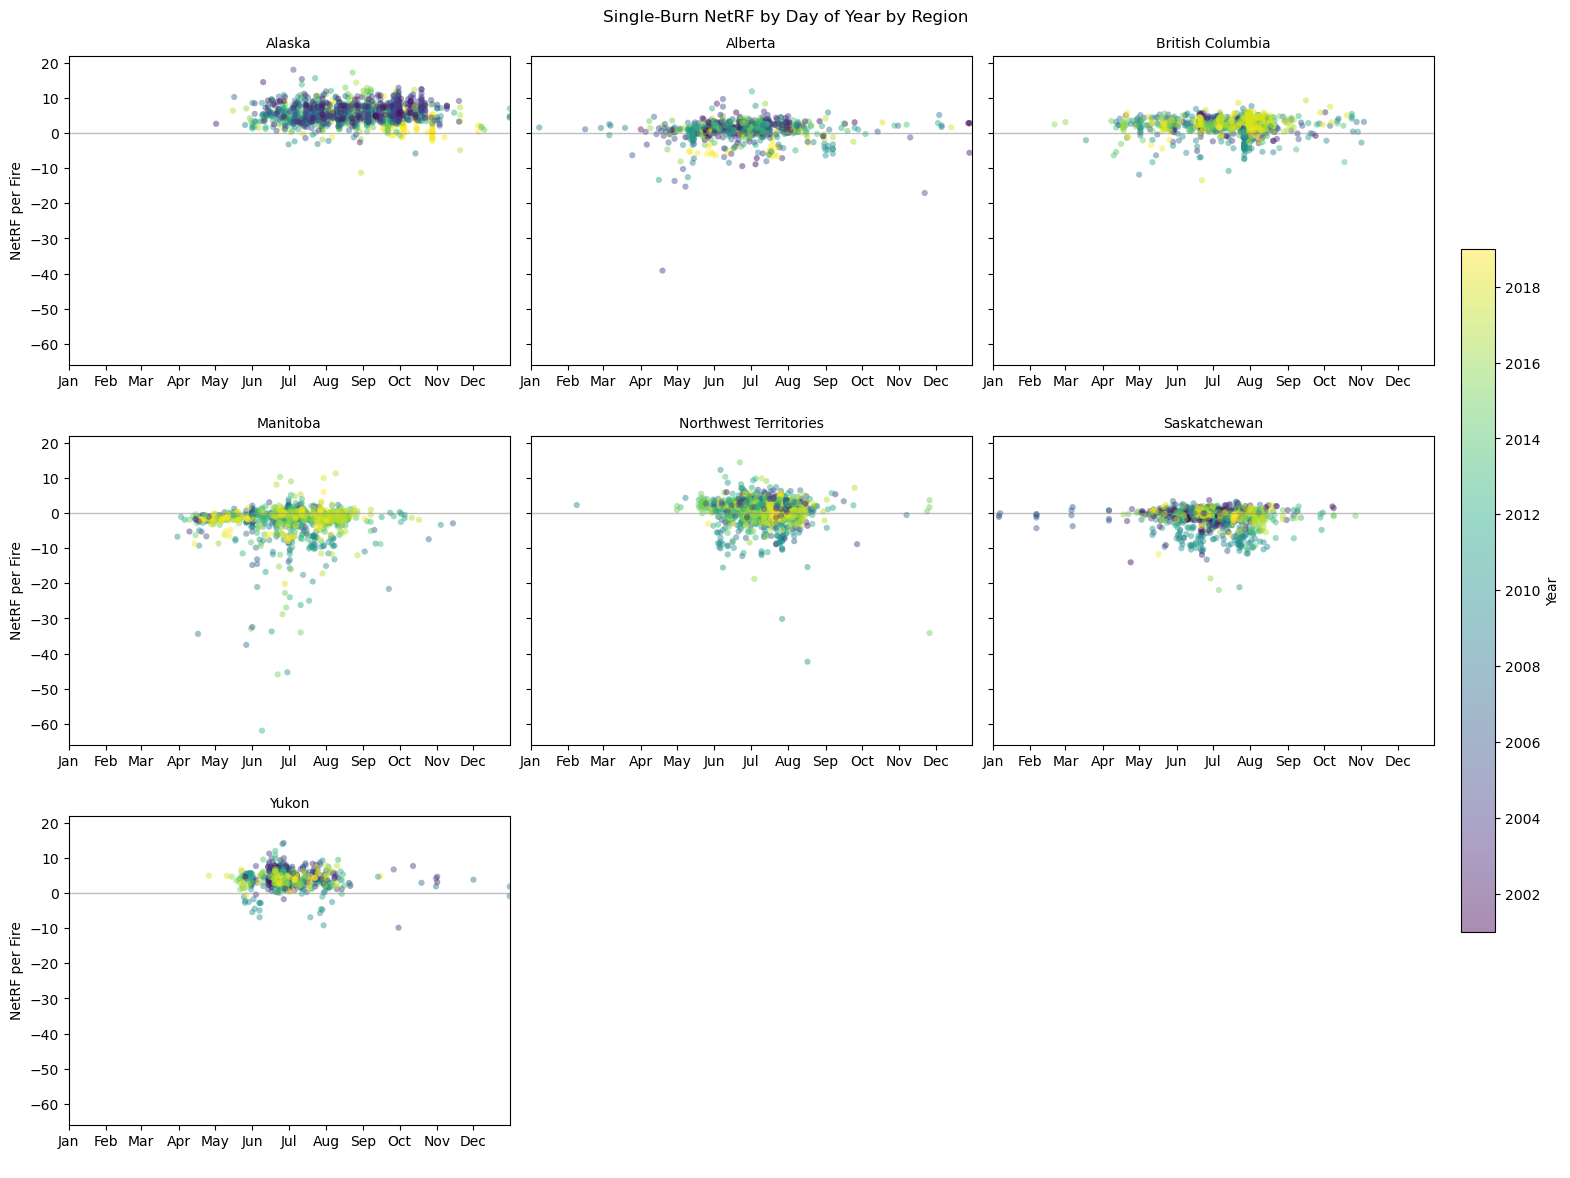

In [66]:
facet_df = df_filter.copy()

year_col = "FIREYEAR" if "FIREYEAR" in facet_df.columns else "YEAR"

facet_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

facet_df = facet_df.dropna(subset=["month_day", "NetRF", year_col, "ctry"]).copy()
facet_df[year_col] = pd.to_numeric(facet_df[year_col], errors="coerce")
facet_df = facet_df.dropna(subset=[year_col]).copy()

eco_order = sorted(facet_df["ctry"].astype(str).unique())
n_eco = len(eco_order)
ncols = 3
nrows = int(np.ceil(n_eco / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.8 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )
axes = np.atleast_1d(axes).flatten()

x_start = pd.Timestamp("2004-01-01")
x_end = pd.Timestamp("2004-12-31")

for ax, eco_name in zip(axes, eco_order):
    sub = facet_df[facet_df["ctry"] == eco_name]
    scatter = ax.scatter(
        sub["month_day"],
        sub["NetRF"],
        c=sub[year_col],
        cmap="viridis",
        vmin=2001,
        vmax=2019,
        s=20,
        alpha=0.45,
        edgecolors="none",
    )
    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.set_title(str(eco_name), fontsize=10)
    ax.set_xlim(x_start, x_end)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelbottom=True)

# Hide any unused subplot axes.
for ax in axes[n_eco:]:
    ax.set_visible(False)

# Labels on outer edges to reduce clutter.
for i, ax in enumerate(axes[:n_eco]):
    if i % ncols == 0:
        ax.set_ylabel("NetRF per Fire")
    ax.set_xlabel(" ")

cbar = fig.colorbar(scatter, ax=axes[:n_eco], fraction=0.025, pad=0.02)
cbar.set_label("Year")
fig.suptitle("Single-Burn NetRF by Day of Year by Region", y=1.02)

plt.show()

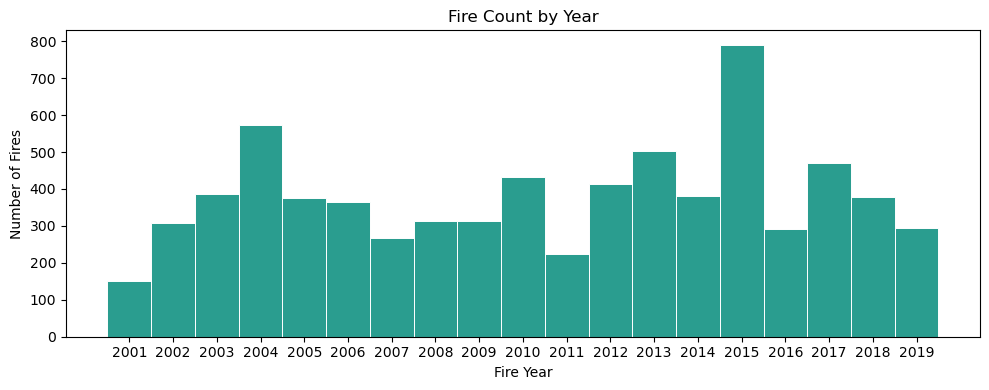

In [22]:
# Histogram of fire counts by year.
hist_df = df_filter.copy()
year_col = "FIREYEAR"
hist_df[year_col] = pd.to_numeric(hist_df[year_col], errors="coerce")
years = hist_df[year_col].dropna().astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(2000.5, 2019.5 + 1, 1)
ax.hist(years, bins=bins, color="#2a9d8f", edgecolor="white", linewidth=0.7)

ax.set_title("Fire Count by Year")
ax.set_xlabel("Fire Year")
ax.set_ylabel("Number of Fires")
ax.set_xticks(np.arange(2001, 2020, 1))

plt.tight_layout()
plt.show()

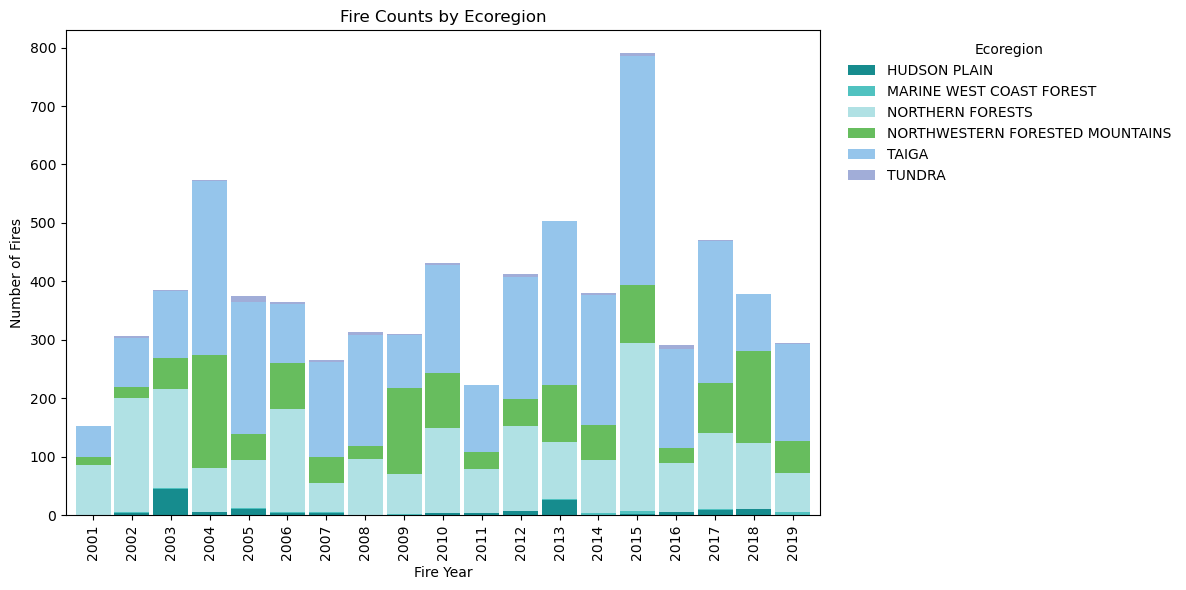

In [10]:
# Stacked bar chart of fire counts by year and ecoregion.
stack_df = df_filter.copy()
stack_df = stack_df[stack_df['eco'] != 'NORTH AMERICAN DESERTS']
stack_df = stack_df[stack_df['eco'] != 'GREAT PLAINS']
stack_df["FIREYEAR"] = pd.to_numeric(stack_df["FIREYEAR"], errors="coerce")
stack_df = stack_df.dropna(subset=["FIREYEAR", "eco"]).copy()
stack_df["FIREYEAR"] = stack_df["FIREYEAR"].astype(int)

year_region_counts = (
    stack_df.groupby(["FIREYEAR", "eco"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Edit these colors as needed for each ecoregion.
region_colors = {
    "GREAT PLAINS": "#F6D19F",
    "HUDSON PLAIN": "#168C8E",
    "MARINE WEST COAST FOREST": "#50C2C0",
    "NORTHERN FORESTS": "#B0E1E4",
    "NORTHWESTERN FORESTED MOUNTAINS": "#67BD5E",
    "TAIGA": "#95C5EB",
    "TUNDRA": "#A1ADD8",
}

plot_colors = [region_colors.get(col, "#bdbdbd") for col in year_region_counts.columns]

fig, ax = plt.subplots(figsize=(12, 6))
year_region_counts.plot(kind="bar", stacked=True, ax=ax, width=0.9, color=plot_colors)

ax.set_title("Fire Counts by Ecoregion")
ax.set_xlabel("Fire Year")
ax.set_ylabel("Number of Fires")
ax.legend(title="Ecoregion", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

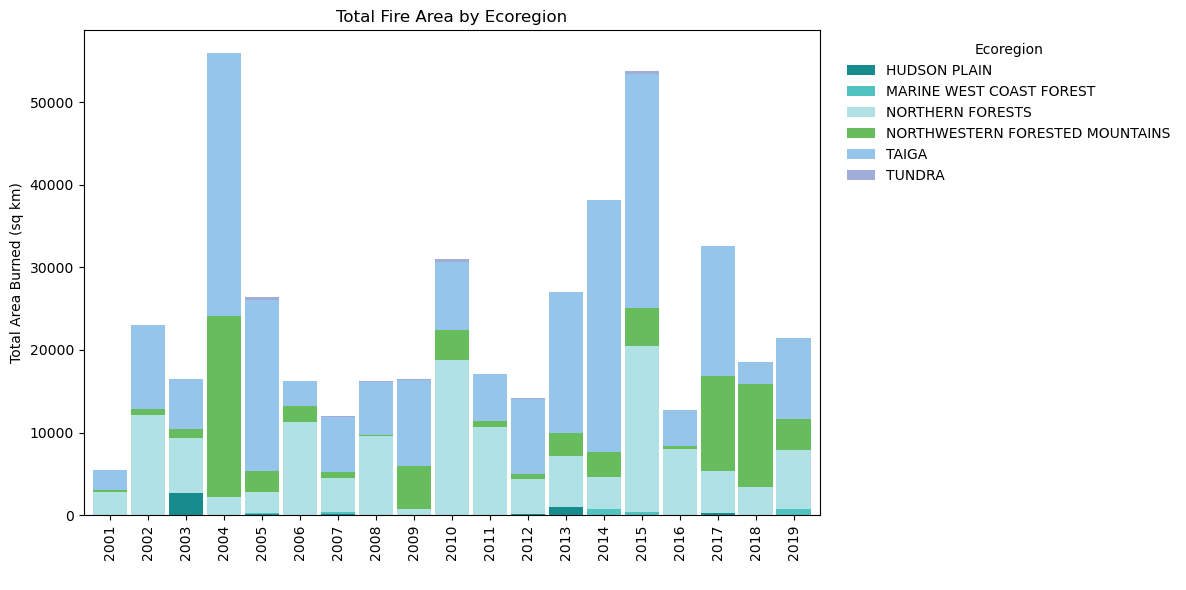

In [12]:
# Stacked bar chart of total fire area (sq km) by year and ecoregion.
stack_df = df_filter.copy()
stack_df = stack_df[stack_df['eco'] != 'NORTH AMERICAN DESERTS']
stack_df = stack_df[stack_df['eco'] != 'GREAT PLAINS']
stack_df["FIREYEAR"] = pd.to_numeric(stack_df["FIREYEAR"], errors="coerce")
stack_df["area_sqkm"] = pd.to_numeric(stack_df["area_sqkm"], errors="coerce")
stack_df = stack_df.dropna(subset=["FIREYEAR", "eco", "area_sqkm"]).copy()
stack_df["FIREYEAR"] = stack_df["FIREYEAR"].astype(int)

year_region_area = (
    stack_df.groupby(["FIREYEAR", "eco"])["area_sqkm"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Edit these colors as needed for each ecoregion.
region_colors = {
    "GREAT PLAINS": "#F6D19F",
    "HUDSON PLAIN": "#168C8E",
    "MARINE WEST COAST FOREST": "#50C2C0",
    "NORTHERN FORESTS": "#B0E1E4",
    "NORTHWESTERN FORESTED MOUNTAINS": "#67BD5E",
    "TAIGA": "#95C5EB",
    "TUNDRA": "#A1ADD8",
}

plot_colors = [region_colors.get(col, "#bdbdbd") for col in year_region_area.columns]

fig, ax = plt.subplots(figsize=(12, 6))
year_region_area.plot(kind="bar", stacked=True, ax=ax, width=0.9, color=plot_colors)

ax.set_title("Total Fire Area by Ecoregion")
ax.set_xlabel(" ")
ax.set_ylabel("Total Area Burned (sq km)")
ax.legend(title="Ecoregion", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

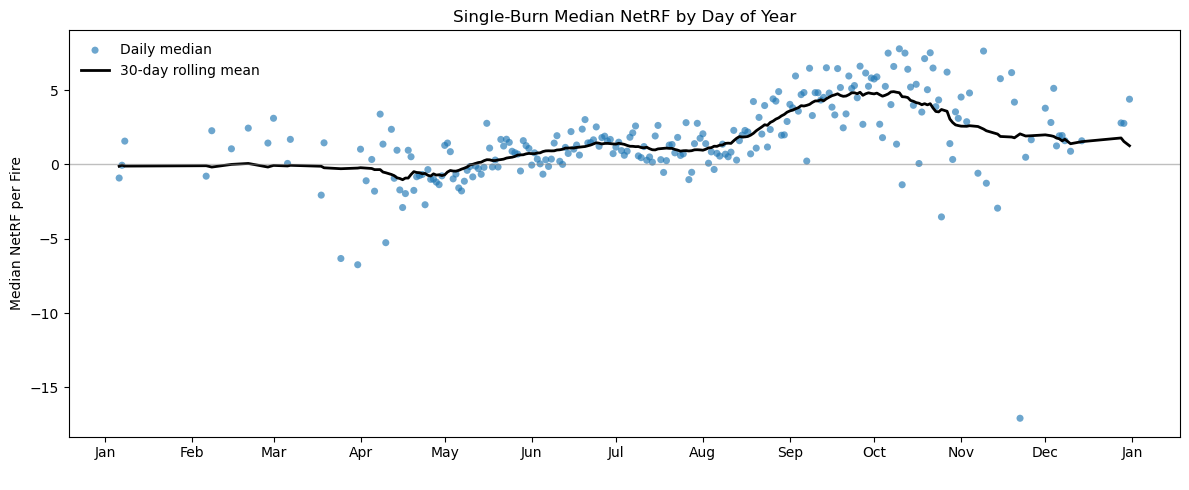

In [47]:
# Median NetRF by calendar day (month + day), with rolling mean overlay.
import matplotlib.dates as mdates

median_df = df_filter.copy()

median_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

median_by_day = (
    median_df.dropna(subset=["month_day", "NetRF"])
    .groupby("month_day", as_index=False)
    .agg(NetRF_median=("NetRF", "median"))
    .sort_values("month_day")
)

# Rolling mean over daily medians (window in days).
window_days = 30
median_by_day["rolling_mean"] = (
    median_by_day["NetRF_median"].rolling(window=window_days, center=True, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    median_by_day["month_day"],
    median_by_day["NetRF_median"],
    s=26,
    alpha=0.65,
    edgecolors="none",
    label="Daily median",
)
ax.plot(
    median_by_day["month_day"],
    median_by_day["rolling_mean"],
    color="black",
    linewidth=2,
    label=f"{window_days}-day rolling mean",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn Median NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("Median NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

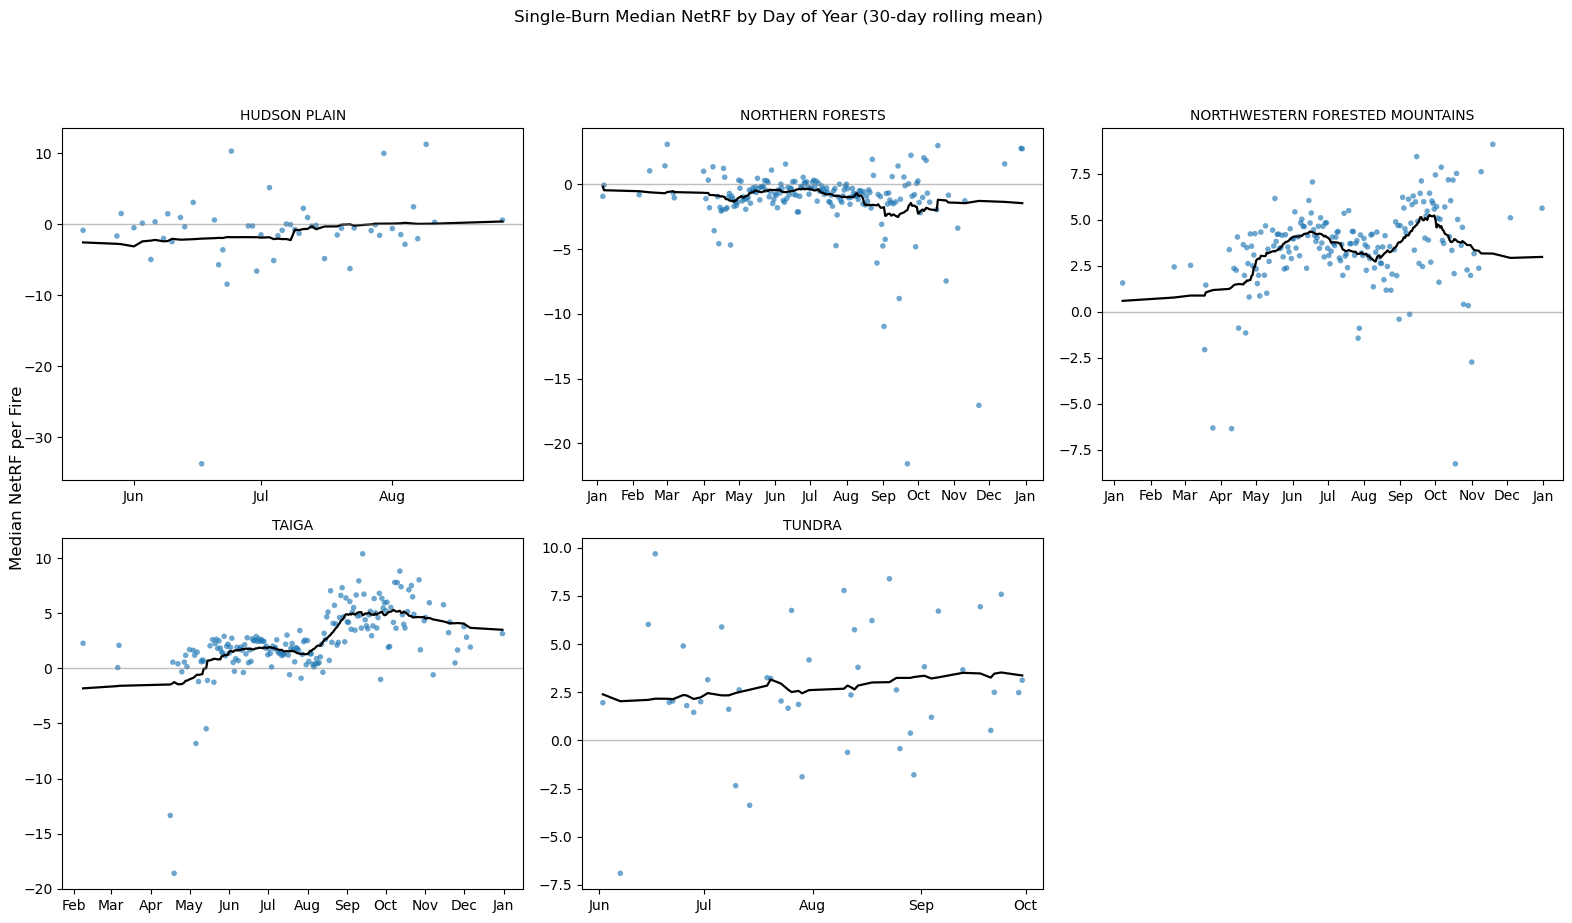

In [48]:
# Median NetRF by calendar day for each region, with 30-day rolling mean.
import matplotlib.dates as mdates

region_median_df = df_filter.copy()

region_median_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

regions = sorted(
    r
    for r in region_median_df["eco"].dropna().unique()
    if r != "NORTH AMERICAN DESERTS" and r != "GREAT PLAINS" and r != "MARINE WEST COAST FOREST"
)

n_cols = 3
n_rows = 2
window_days = 30

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_daily = (
        region_median_df.loc[region_median_df["eco"] == region]
        .dropna(subset=["month_day", "NetRF"])
        .groupby("month_day", as_index=False)
        .agg(NetRF_median=("NetRF", "median"))
        .sort_values("month_day")
    )

    region_daily["rolling_mean"] = (
        region_daily["NetRF_median"].rolling(window=window_days, center=True, min_periods=1).mean()
    )

    ax.scatter(
        region_daily["month_day"],
        region_daily["NetRF_median"],
        s=16,
        alpha=0.65,
        edgecolors="none",
    )
    ax.plot(
        region_daily["month_day"],
        region_daily["rolling_mean"],
        color="black",
        linewidth=1.6,
    )

    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(region, fontsize=10)

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.supylabel("Median NetRF per Fire")
fig.suptitle("Single-Burn Median NetRF by Day of Year (30-day rolling mean)", y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

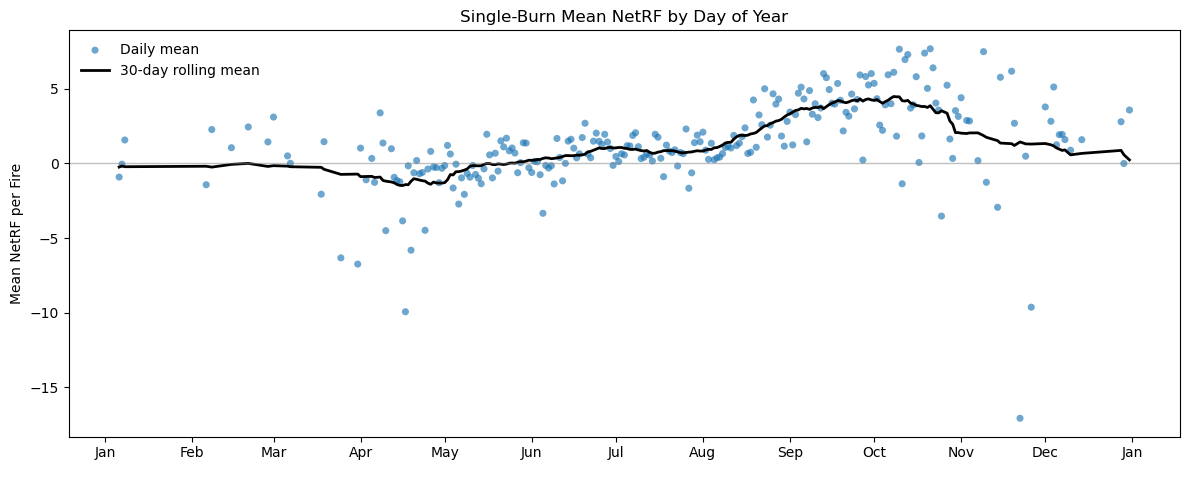

In [28]:
# Mean NetRF by calendar day (month + day), with rolling mean overlay.
mean_by_day = (
    median_df.dropna(subset=["month_day", "NetRF"])
    .groupby("month_day", as_index=False)
    .agg(NetRF_mean=("NetRF", "mean"))
    .sort_values("month_day")
)

mean_by_day["rolling_mean"] = (
    mean_by_day["NetRF_mean"].rolling(window=window_days, center=True, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    mean_by_day["month_day"],
    mean_by_day["NetRF_mean"],
    s=26,
    alpha=0.65,
    edgecolors="none",
    label="Daily mean",
)
ax.plot(
    mean_by_day["month_day"],
    mean_by_day["rolling_mean"],
    color="black",
    linewidth=2,
    label=f"{window_days}-day rolling mean",
)
ax.axhline(0, color="gray", linewidth=1, alpha=0.5)

ax.set_title("Single-Burn Mean NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("Mean NetRF per Fire")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

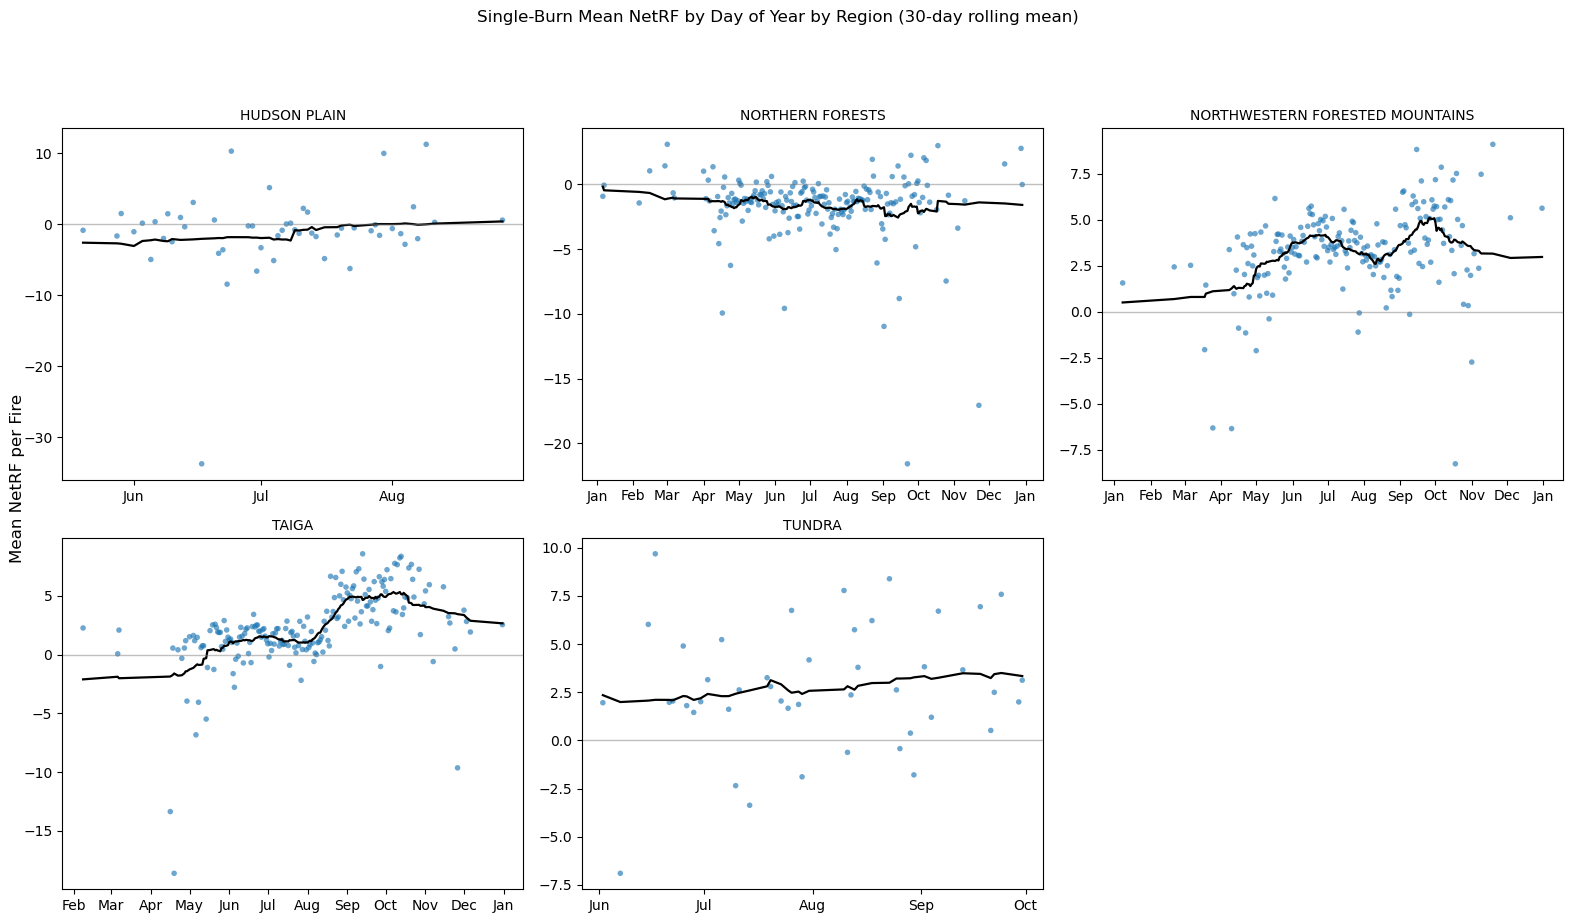

In [49]:
# Mean NetRF by calendar day for each region, with 30-day rolling mean.
import matplotlib.dates as mdates

region_mean_df = df_filter.copy()

region_mean_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

regions = sorted(
    r
    for r in region_mean_df["eco"].dropna().unique()
    if r != "NORTH AMERICAN DESERTS" and r != "GREAT PLAINS" and r != "MARINE WEST COAST FOREST"
)

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))
window_days = 30

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_daily = (
        region_mean_df.loc[region_mean_df["eco"] == region]
        .dropna(subset=["month_day", "NetRF"])
        .groupby("month_day", as_index=False)
        .agg(NetRF_mean=("NetRF", "mean"))
        .sort_values("month_day")
    )

    region_daily["rolling_mean"] = (
        region_daily["NetRF_mean"].rolling(window=window_days, center=True, min_periods=1).mean()
    )

    ax.scatter(
        region_daily["month_day"],
        region_daily["NetRF_mean"],
        s=16,
        alpha=0.65,
        edgecolors="none",
    )
    ax.plot(
        region_daily["month_day"],
        region_daily["rolling_mean"],
        color="black",
        linewidth=1.6,
    )

    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(region, fontsize=10)

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.supylabel("Mean NetRF per Fire")
fig.suptitle("Single-Burn Mean NetRF by Day of Year by Region (30-day rolling mean)", y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

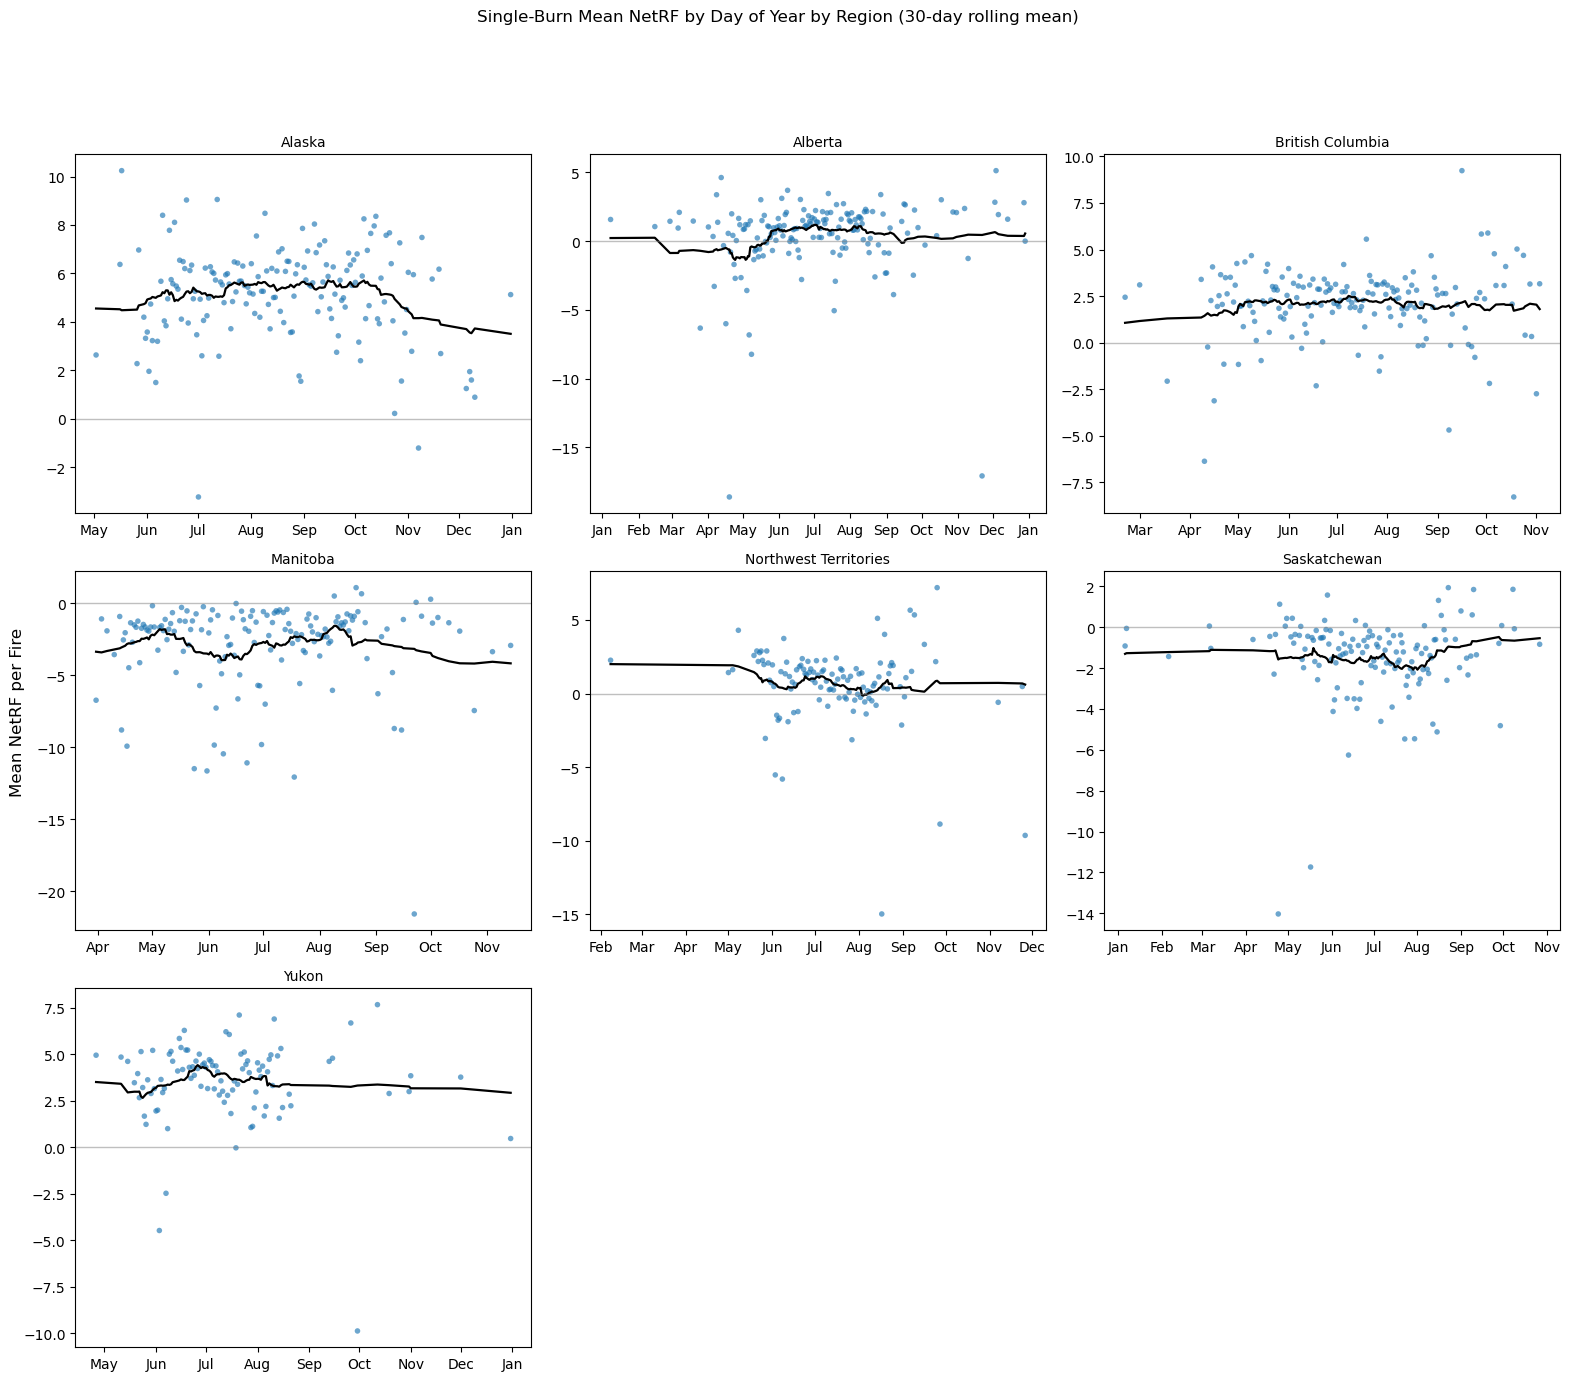

In [50]:
region_mean_df = df_filter.copy()

region_mean_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": month_source,
        "day": day_source,
    },
    errors="coerce",
)

regions = sorted(
    r for r in region_mean_df["ctry"].dropna().unique()
)

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))
window_days = 30

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_daily = (
        region_mean_df.loc[region_mean_df["ctry"] == region]
        .dropna(subset=["month_day", "NetRF"])
        .groupby("month_day", as_index=False)
        .agg(NetRF_mean=("NetRF", "mean"))
        .sort_values("month_day")
    )

    if region_daily.empty:
        ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
        ax.text(
            0.5,
            0.5,
            "No valid date\n(REP_DATE/FPOUTDATE/MONTH+DAY)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.7,
        )
        ax.set_title(region, fontsize=10)
        ax.set_xlim(pd.Timestamp("2004-01-01"), pd.Timestamp("2004-12-31"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        continue

    region_daily["rolling_mean"] = (
        region_daily["NetRF_mean"].rolling(window=window_days, center=True, min_periods=1).mean()
    )

    ax.scatter(
        region_daily["month_day"],
        region_daily["NetRF_mean"],
        s=16,
        alpha=0.65,
        edgecolors="none",
    )
    ax.plot(
        region_daily["month_day"],
        region_daily["rolling_mean"],
        color="black",
        linewidth=1.6,
    )

    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(region, fontsize=10)

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.supylabel("Mean NetRF per Fire")
fig.suptitle("Single-Burn Mean NetRF by Day of Year by Region (30-day rolling mean)", y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
#netRF by year, or decade, and by year/decade by ecoregion

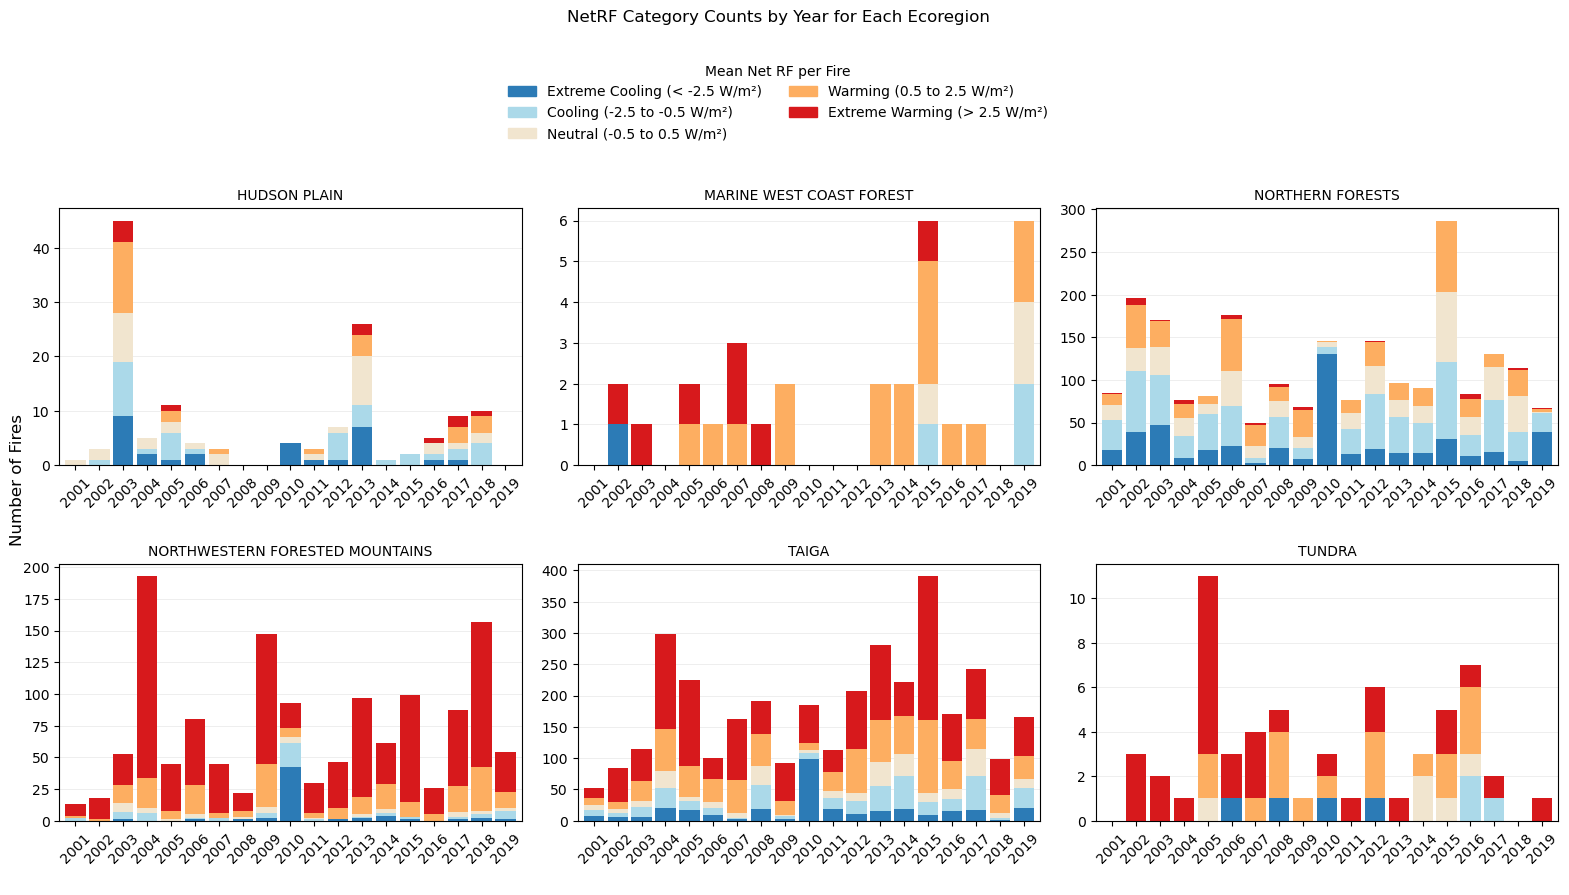

In [17]:
bins = [-100, -2.5, -0.5, 0.5, 2.5, 100]
labels = ["Extreme Cooling", "Cooling", "Neutral", "Warming", "Extreme Warming"]

# Edit these colors to change the stacked category colors.
category_colors = {
    "Extreme Cooling": "#2c7bb6",
    "Cooling": "#abd9e9",
    "Neutral": "#f1e5cf",
    "Warming": "#fdae61",
    "Extreme Warming": "#d7191c",
}

# Legend labels that include the numeric range for each category, with the
# extremes shown as cutoff values rather than full outside-range bounds.
category_range_labels = {
    labels[0]: f"{labels[0]} (< {bins[1]} W/m²)",
    labels[1]: f"{labels[1]} ({bins[1]} to {bins[2]} W/m²)",
    labels[2]: f"{labels[2]} ({bins[2]} to {bins[3]} W/m²)",
    labels[3]: f"{labels[3]} ({bins[3]} to {bins[4]} W/m²)",
    labels[4]: f"{labels[4]} (> {bins[-2]} W/m²)",
}

cat_df = df_filter.copy()
cat_df = cat_df[cat_df['eco'] != 'NORTH AMERICAN DESERTS']
cat_df = cat_df[cat_df['eco'] != 'GREAT PLAINS']
cat_df["FIREYEAR"] = pd.to_numeric(cat_df["FIREYEAR"], errors="coerce")  ##replace all this with the category column
cat_df["NetRF"] = pd.to_numeric(cat_df["NetRF"], errors="coerce")
cat_df = cat_df.dropna(subset=["FIREYEAR", "NetRF", "eco"]).copy()
cat_df["FIREYEAR"] = cat_df["FIREYEAR"].astype(int)

cat_df["NetRF_category"] = pd.cut(
    cat_df["NetRF"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True,
)
cat_df = cat_df.dropna(subset=["NetRF_category"]).copy()

regions = sorted(cat_df["eco"].unique())
all_years = list(range(cat_df["FIREYEAR"].min(), cat_df["FIREYEAR"].max() + 1))

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_counts = (
        cat_df.loc[cat_df["eco"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

fig.suptitle("NetRF Category Counts by Year for Each Ecoregion", y=1.06)
fig.supylabel("Number of Fires")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

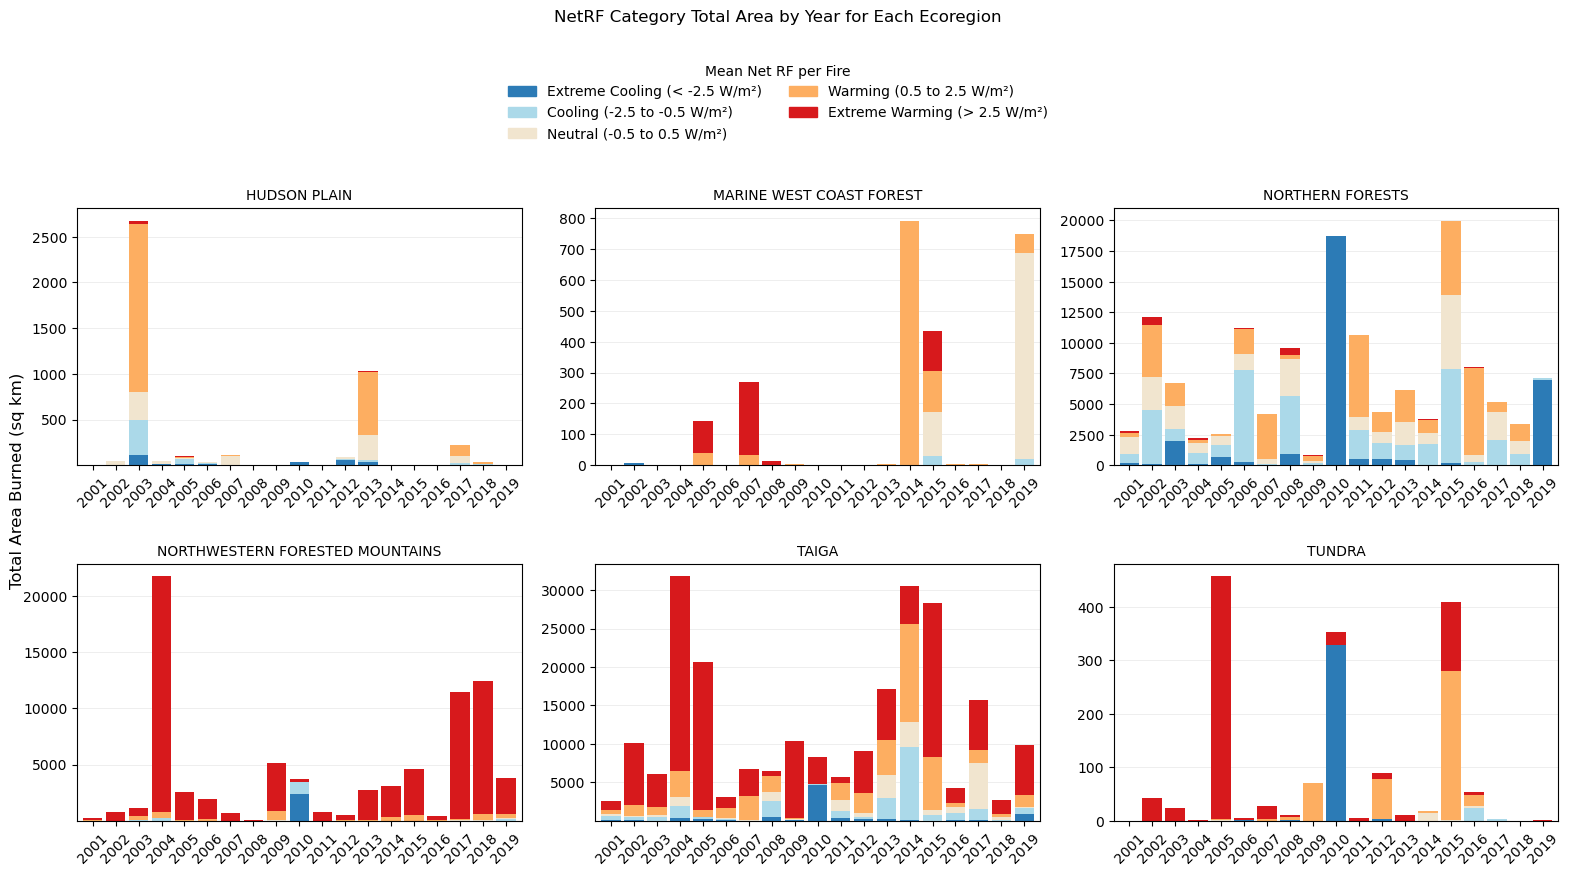

In [18]:
cat_df = df_filter.copy()
cat_df = cat_df[cat_df['eco'] != 'NORTH AMERICAN DESERTS']
cat_df = cat_df[cat_df['eco'] != 'GREAT PLAINS']
cat_df["FIREYEAR"] = pd.to_numeric(cat_df["FIREYEAR"], errors="coerce")
cat_df["NetRF"] = pd.to_numeric(cat_df["NetRF"], errors="coerce")
cat_df["area_sqkm"] = pd.to_numeric(cat_df["area_sqkm"], errors="coerce")
cat_df = cat_df.dropna(subset=["FIREYEAR", "NetRF", "eco", "area_sqkm"]).copy()
cat_df["FIREYEAR"] = cat_df["FIREYEAR"].astype(int)

cat_df["NetRF_category"] = pd.cut(
    cat_df["NetRF"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True,
)
cat_df = cat_df.dropna(subset=["NetRF_category"]).copy()

regions = sorted(cat_df["eco"].unique())
all_years = list(range(cat_df["FIREYEAR"].min(), cat_df["FIREYEAR"].max() + 1))

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_area = (
        cat_df.loc[cat_df["eco"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)["area_sqkm"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_area.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

fig.suptitle("NetRF Category Total Area by Year for Each Ecoregion", y=1.06)
fig.supylabel("Total Area Burned (sq km)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

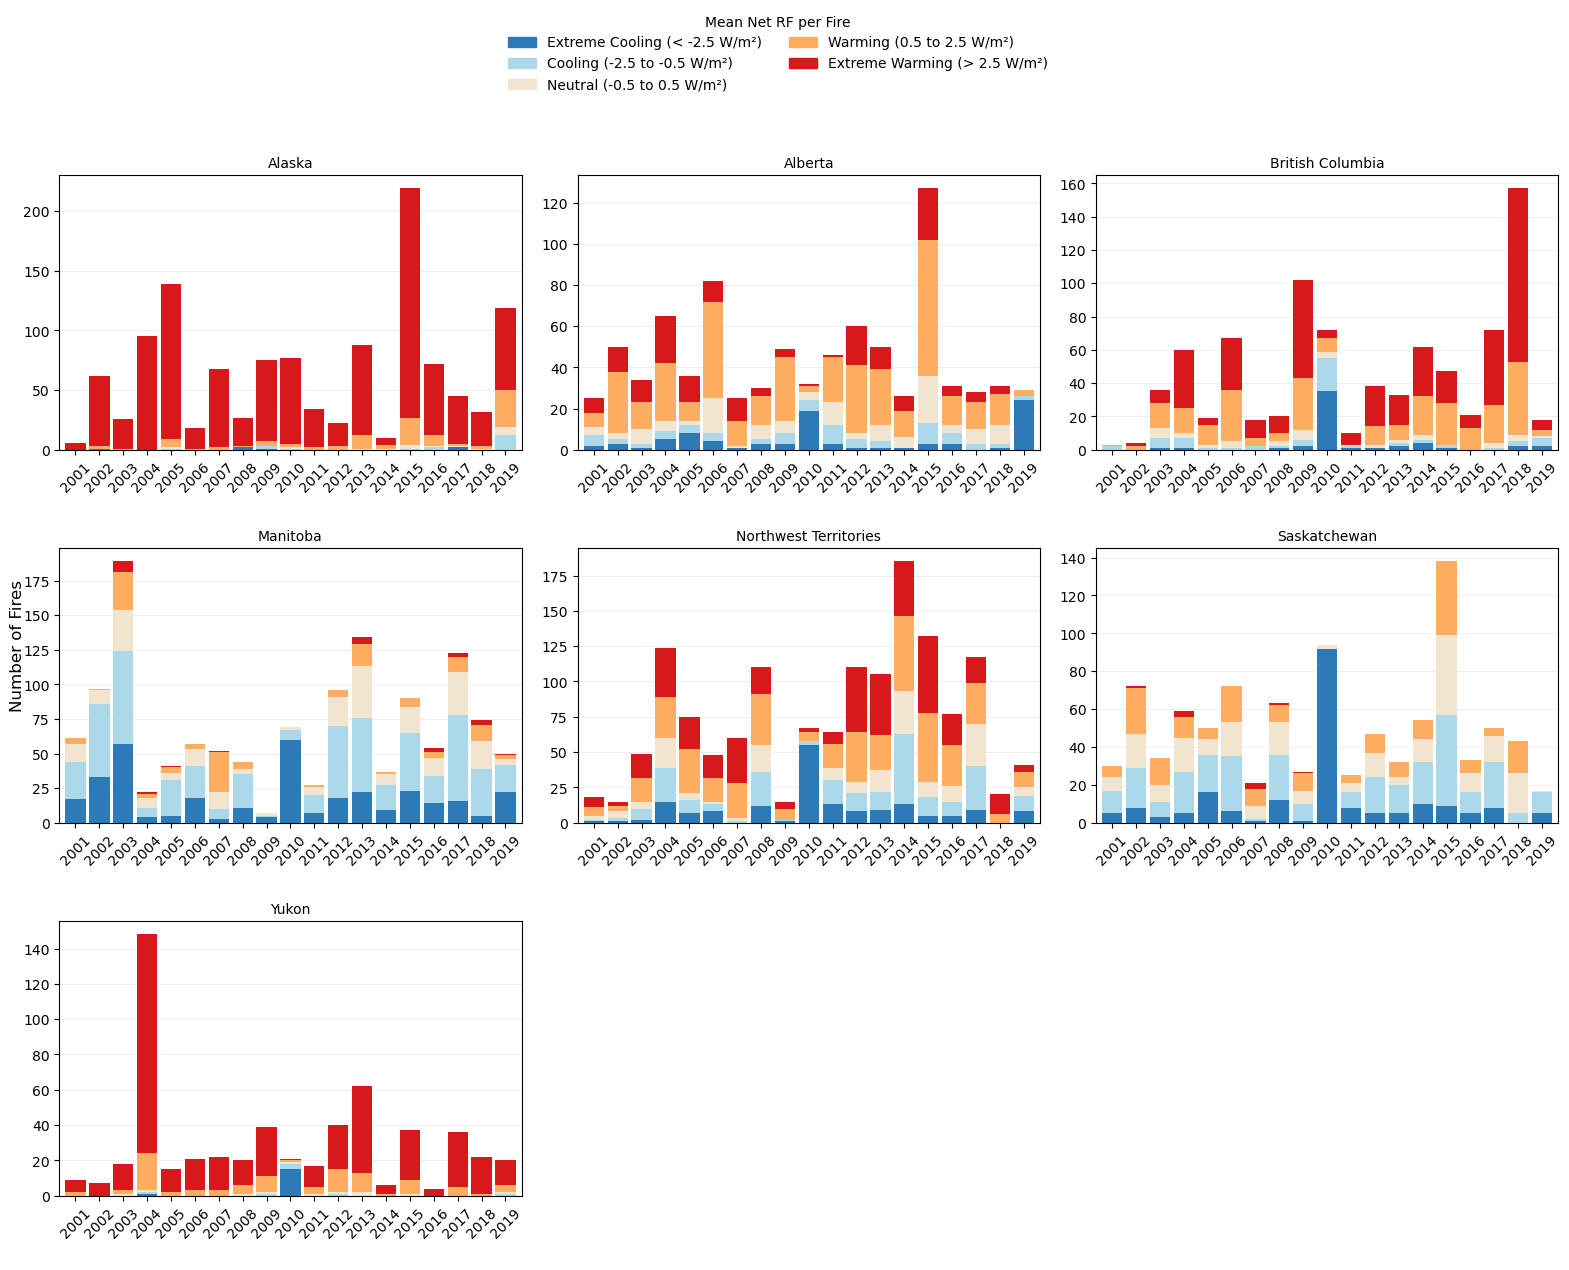

In [34]:
cat_df = df_filter.copy()
cat_df["FIREYEAR"] = pd.to_numeric(cat_df["FIREYEAR"], errors="coerce")
cat_df["NetRF"] = pd.to_numeric(cat_df["NetRF"], errors="coerce")
cat_df = cat_df.dropna(subset=["FIREYEAR", "NetRF", "ctry"]).copy()
cat_df["FIREYEAR"] = cat_df["FIREYEAR"].astype(int)

cat_df["NetRF_category"] = pd.cut(
    cat_df["NetRF"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True,
)
cat_df = cat_df.dropna(subset=["NetRF_category"]).copy()

regions = sorted(cat_df["ctry"].unique())
all_years = list(range(cat_df["FIREYEAR"].min(), cat_df["FIREYEAR"].max() + 1))

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_counts = (
        cat_df.loc[cat_df["ctry"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)
fig.supylabel("Number of Fires")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

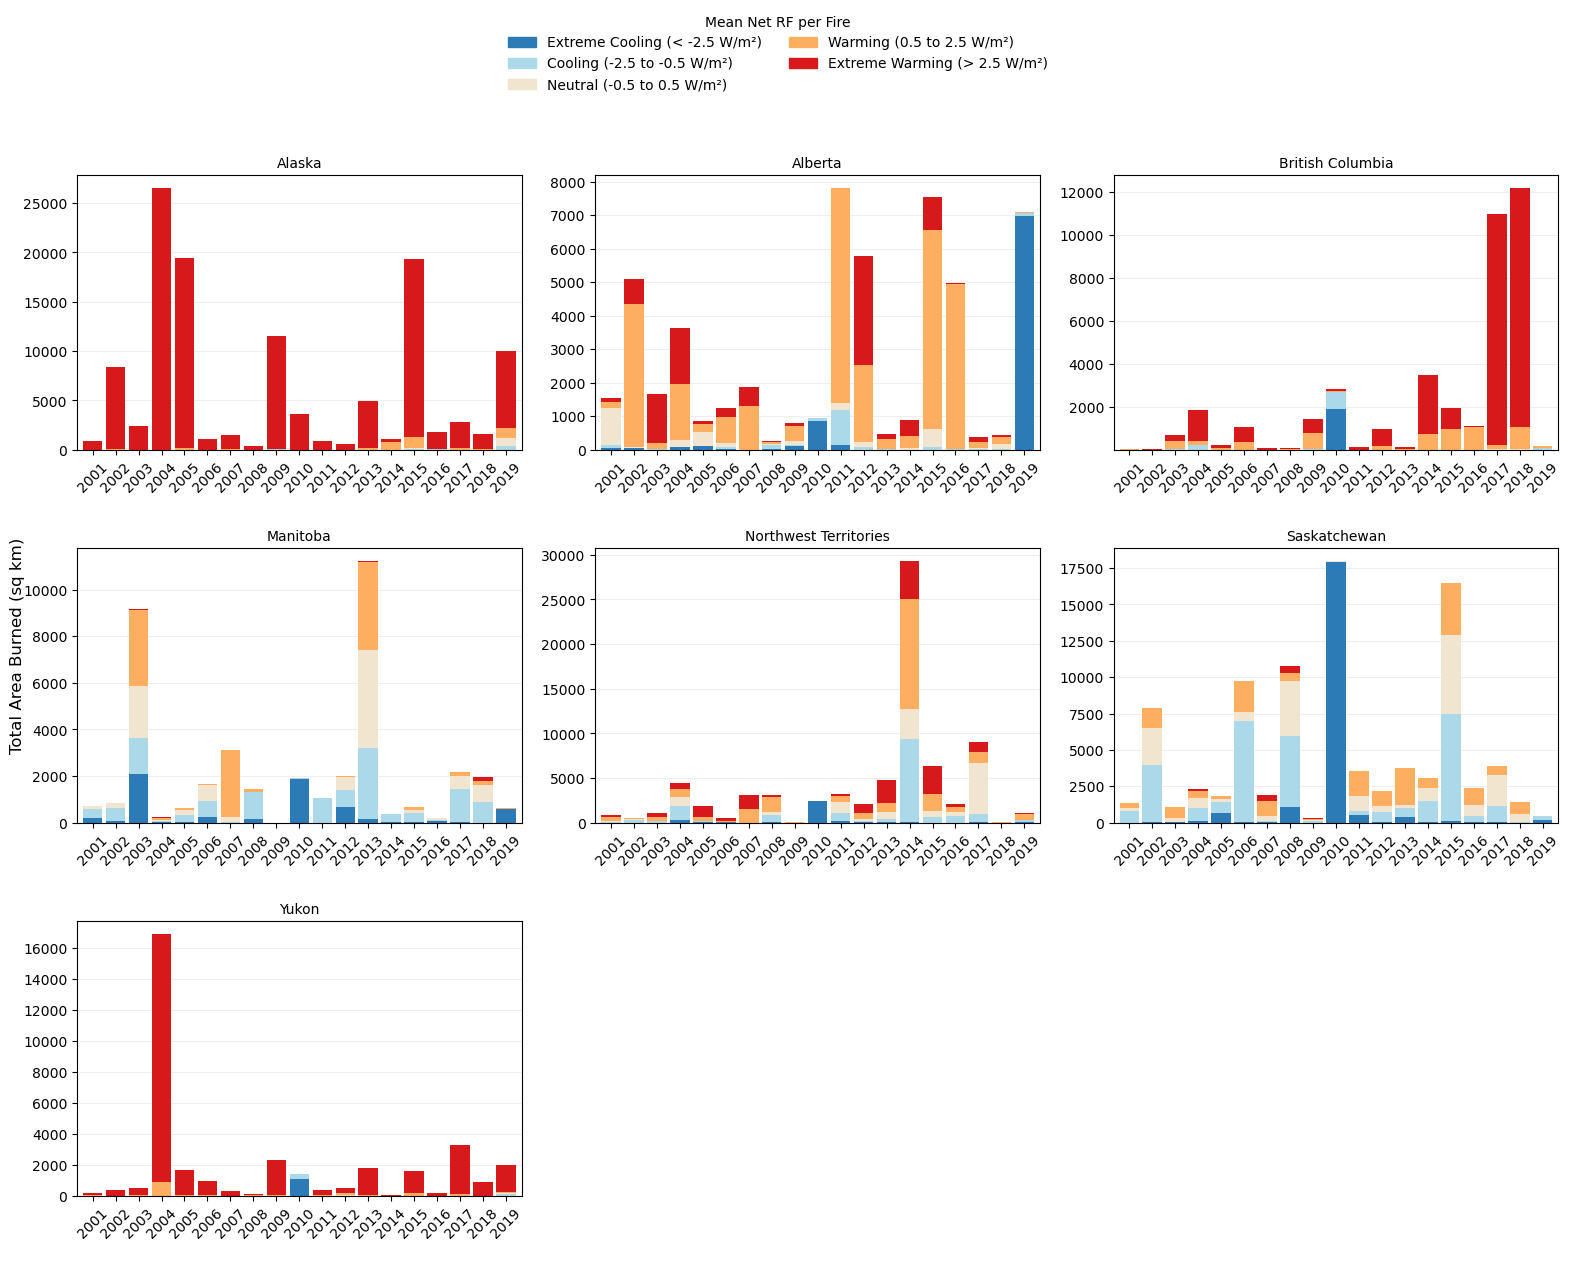

In [19]:
regions = sorted(cat_df["ctry"].unique())
all_years = list(range(cat_df["FIREYEAR"].min(), cat_df["FIREYEAR"].max() + 1))

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_area = (
        cat_df.loc[cat_df["ctry"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)["area_sqkm"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_area.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

fig.supylabel("Total Area Burned (sq km)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

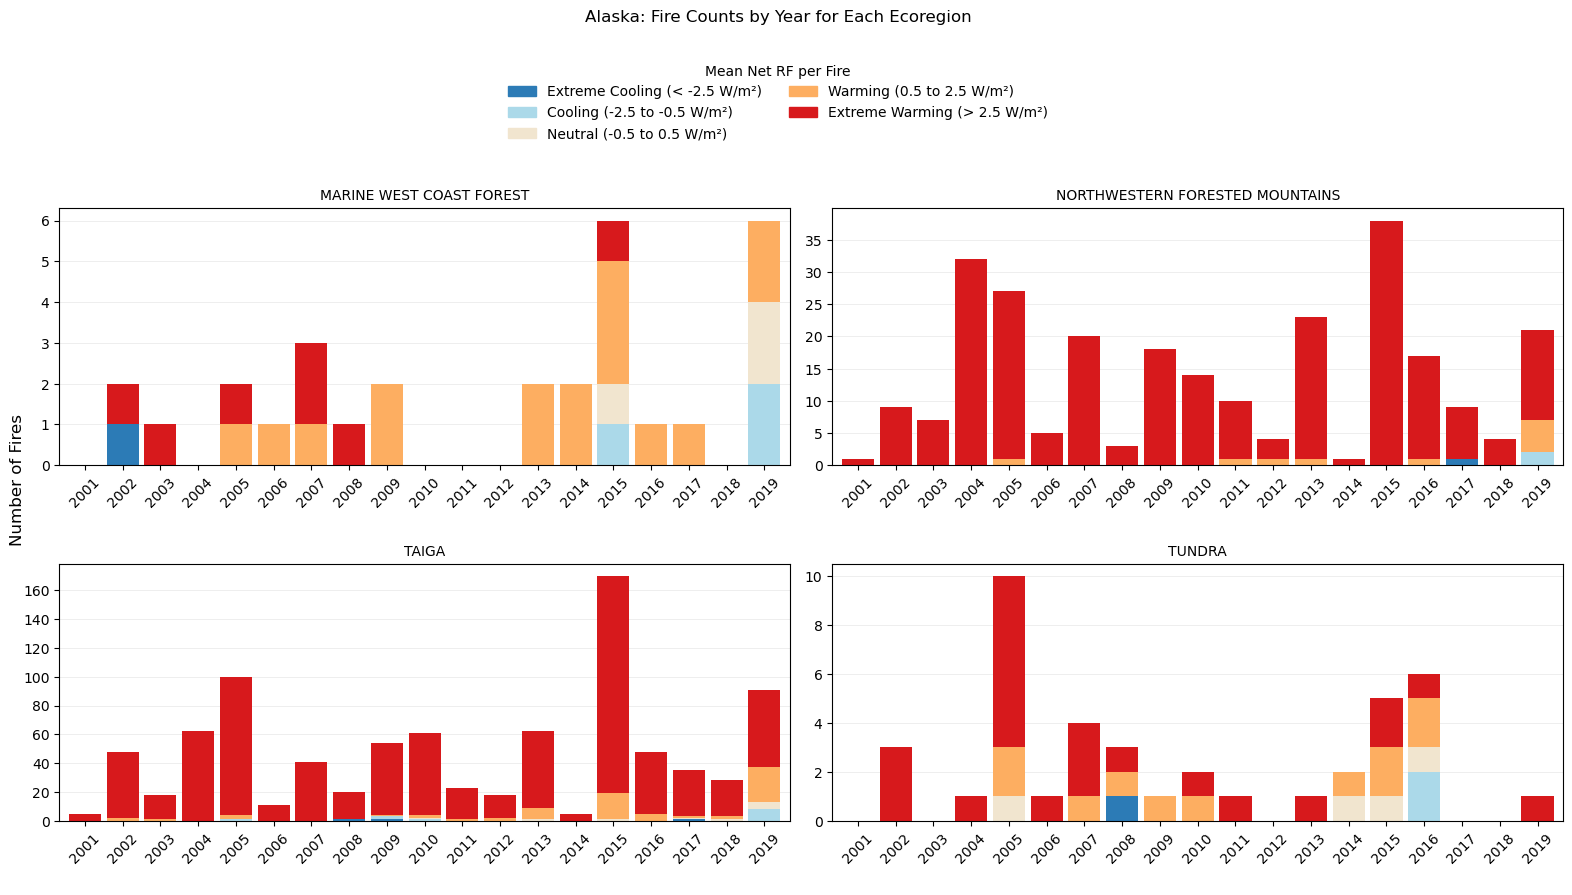

In [37]:
ak_df = df_filter[df_filter["ctry"] == "Alaska"].copy()
ak_df["FIREYEAR"] = pd.to_numeric(ak_df["FIREYEAR"], errors="coerce")
ak_df["NetRF"] = pd.to_numeric(ak_df["NetRF"], errors="coerce")
ak_df = ak_df.dropna(subset=["FIREYEAR", "NetRF", "ctry"]).copy()
ak_df["FIREYEAR"] = ak_df["FIREYEAR"].astype(int)

ak_df["NetRF_category"] = pd.cut(
    ak_df["NetRF"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True,
)
regions = sorted(ak_df["eco"].unique())
all_years = list(range(ak_df["FIREYEAR"].min(), ak_df["FIREYEAR"].max() + 1))

n_cols = 2
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=False,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_counts = (
        ak_df.loc[ak_df["eco"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)
    
    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)
    
    for ax in axes[len(regions):]:
        ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

fig.suptitle("Alaska: Fire Counts by Year for Each Ecoregion", y=1.06)
fig.supylabel("Number of Fires")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

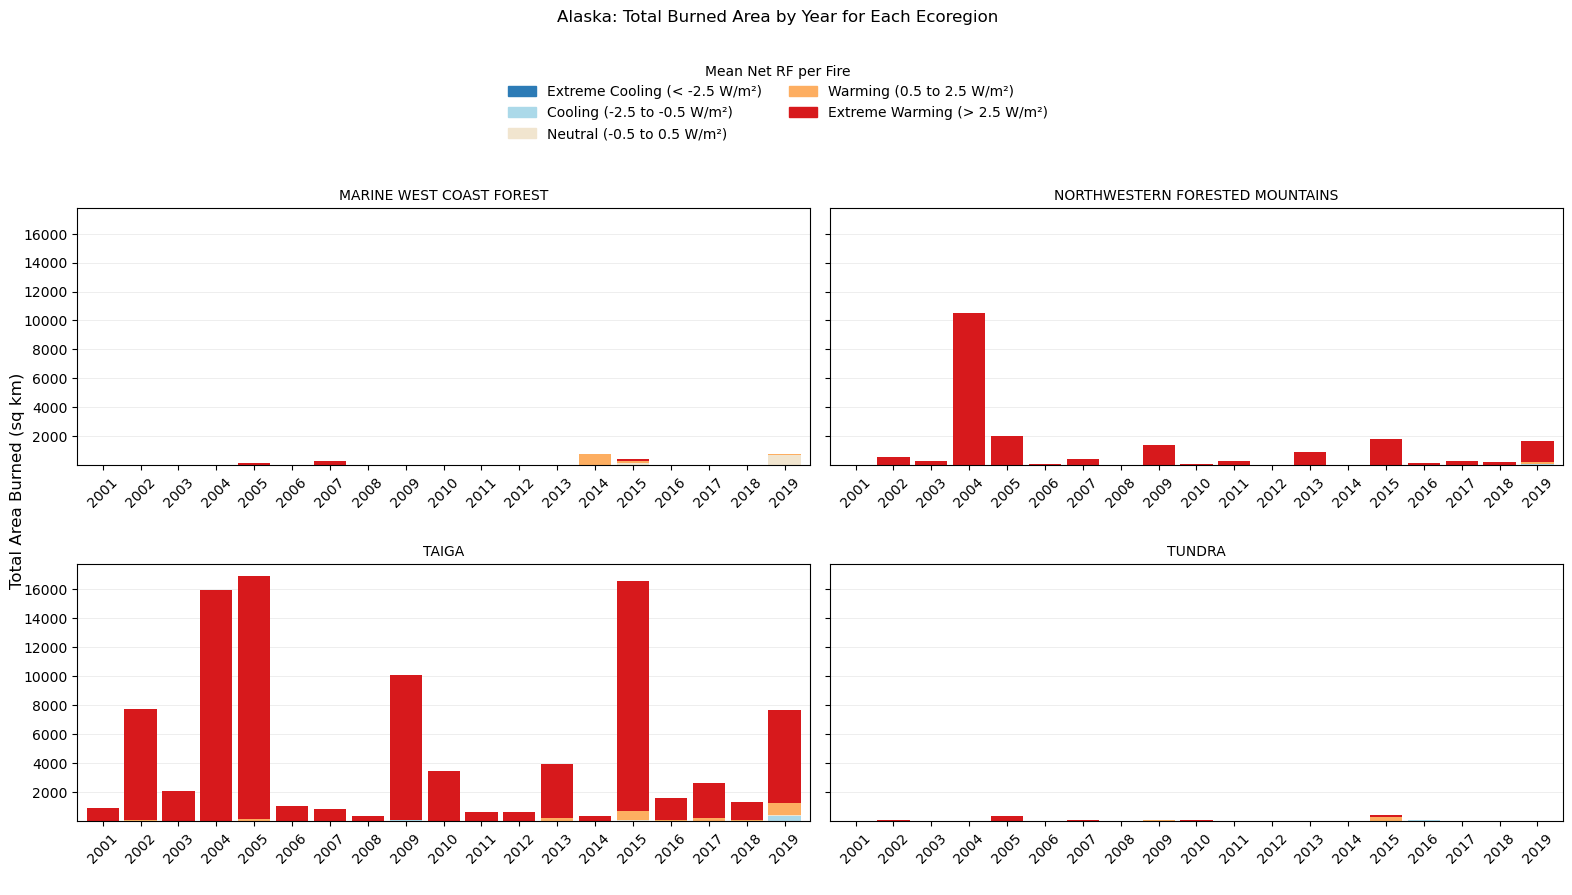

In [22]:
ak_df = df_filter[df_filter["ctry"] == "Alaska"].copy()
ak_df["FIREYEAR"] = pd.to_numeric(ak_df["FIREYEAR"], errors="coerce")
ak_df["NetRF"] = pd.to_numeric(ak_df["NetRF"], errors="coerce")
ak_df = ak_df.dropna(subset=["FIREYEAR", "NetRF", "ctry"]).copy()
ak_df["FIREYEAR"] = ak_df["FIREYEAR"].astype(int)

ak_df["NetRF_category"] = pd.cut(
    ak_df["NetRF"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    ordered=True,
)
regions = sorted(ak_df["eco"].unique())
all_years = list(range(ak_df["FIREYEAR"].min(), ak_df["FIREYEAR"].max() + 1))

n_cols = 2
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.2 * n_rows),
    sharex=False,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_counts = (
        ak_df.loc[ak_df["eco"] == region]
        .groupby(["FIREYEAR", "NetRF_category"], observed=True)["area_sqkm"]
        .sum()
        .unstack(fill_value=0)
        .reindex(index=all_years, fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    region_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85,
        color=[category_colors[label] for label in labels],
        legend=False,
    )

    ax.set_title(region, fontsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel(" ")
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)
    
    tick_step = 1
    tick_positions = np.arange(0, len(all_years), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_years[i] for i in tick_positions], rotation=45)
    ax.tick_params(axis="x", labelbottom=True)
    
    for ax in axes[len(regions):]:
        ax.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors[label], label=category_range_labels[label])
    for label in labels
]
fig.legend(
    handles=handles,
    title="Mean Net RF per Fire",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

fig.suptitle("Alaska: Total Burned Area by Year for Each Ecoregion", y=1.06)
fig.supylabel("Total Area Burned (sq km)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

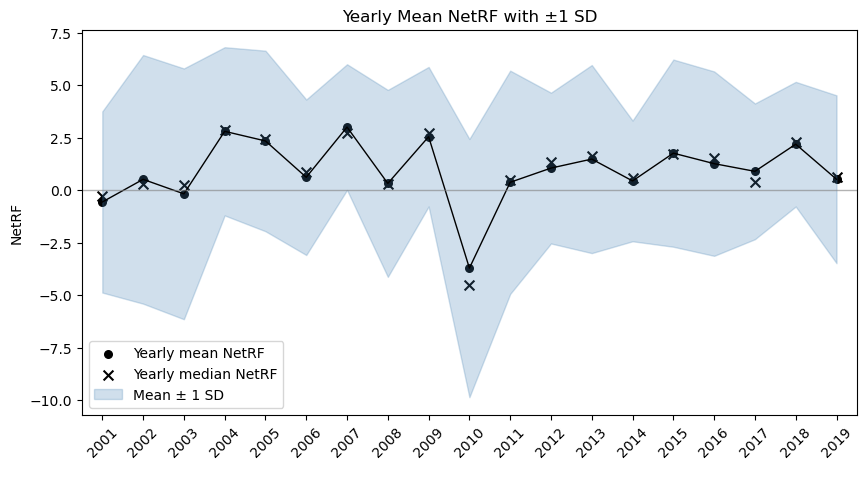

In [38]:
yearly = (
    df_filter.dropna(subset=["FIREYEAR", "NetRF"])
    .groupby("FIREYEAR", as_index=False)["NetRF"]
    .agg(mean="mean", median="median", std="std")
    .sort_values("FIREYEAR")
)

yearly["std"] = yearly["std"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(yearly["FIREYEAR"], yearly["mean"], color="black", s=30, label="Yearly mean NetRF")
ax.plot(yearly["FIREYEAR"], yearly["mean"], color="black", linewidth=1)
ax.scatter(yearly["FIREYEAR"], yearly["median"], color="black", marker="x", s=50, label="Yearly median NetRF")
ax.fill_between(
    yearly["FIREYEAR"],
    yearly["mean"] - yearly["std"],
    yearly["mean"] + yearly["std"],
    color="steelblue",
    alpha=0.25,
    label="Mean ± 1 SD",
)

ax.axhline(0, color="gray", linewidth=1, alpha=0.6)

year_min = int(yearly["FIREYEAR"].min())
year_max = int(yearly["FIREYEAR"].max())
all_years = list(range(year_min, year_max + 1))

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=45)
ax.set_xlim(year_min - 0.5, year_max + 0.5)

ax.set_xlabel(" ")
ax.set_ylabel("NetRF")
ax.set_title("Yearly Mean NetRF with ±1 SD")
ax.legend()

plt.show()

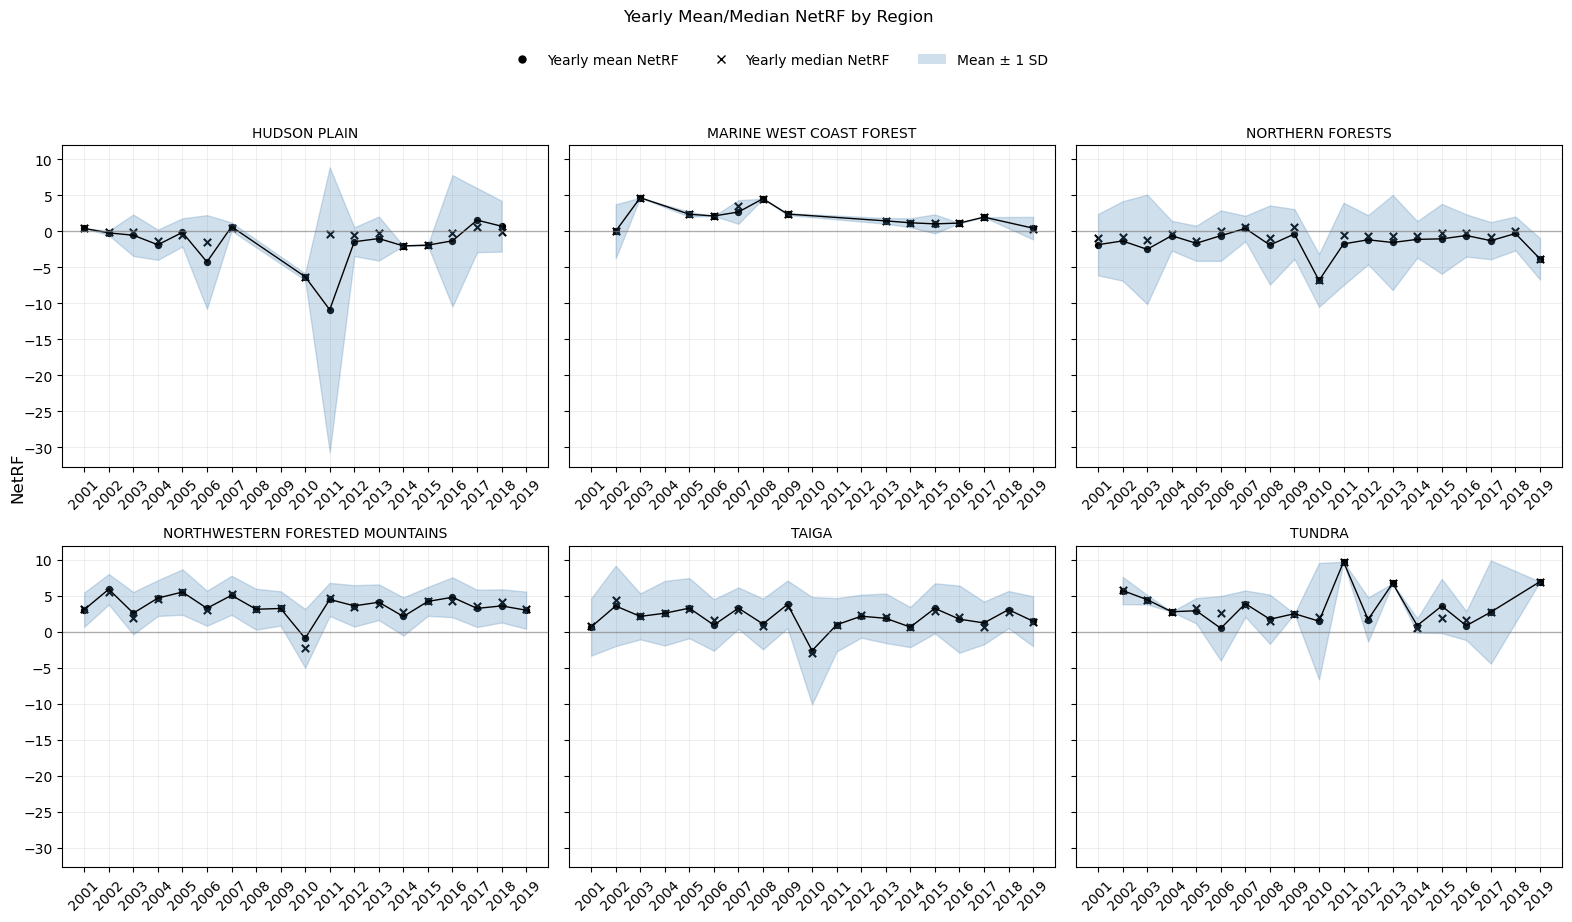

In [39]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

regions = sorted(
    r
    for r in df_filter["eco"].dropna().unique()
    if r != "NORTH AMERICAN DESERTS" and r != "GREAT PLAINS" 
)

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_yearly = (
        df_filter.loc[df_filter["eco"] == region]
        .dropna(subset=["FIREYEAR", "NetRF"])
        .groupby("FIREYEAR", as_index=False)["NetRF"]
        .agg(mean="mean", median="median", std="std")
        .sort_values("FIREYEAR")
    )

    region_yearly["std"] = region_yearly["std"].fillna(0)

    ax.set_axisbelow(True)
    ax.grid(axis='both', linestyle='-', linewidth=0.6, alpha=0.25)
    ax.scatter(region_yearly["FIREYEAR"], region_yearly["mean"], color="black", s=18)
    ax.plot(region_yearly["FIREYEAR"], region_yearly["mean"], color="black", linewidth=1)
    ax.scatter(
        region_yearly["FIREYEAR"],
        region_yearly["median"],
        color="black",
        marker="x",
        s=28,
    )
    ax.fill_between(
        region_yearly["FIREYEAR"],
        region_yearly["mean"] - region_yearly["std"],
        region_yearly["mean"] + region_yearly["std"],
        color="steelblue",
        alpha=0.25,
    )

    ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_title(region, fontsize=10)
    ax.tick_params(axis='x', labelbottom=True, rotation=45)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=5, label="Yearly mean NetRF"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=6, label="Yearly median NetRF"),
    Patch(facecolor="steelblue", alpha=0.25, label="Mean ± 1 SD"),
]

fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=3, frameon=False)

fig.supylabel("NetRF")
fig.suptitle("Yearly Mean/Median NetRF by Region", y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

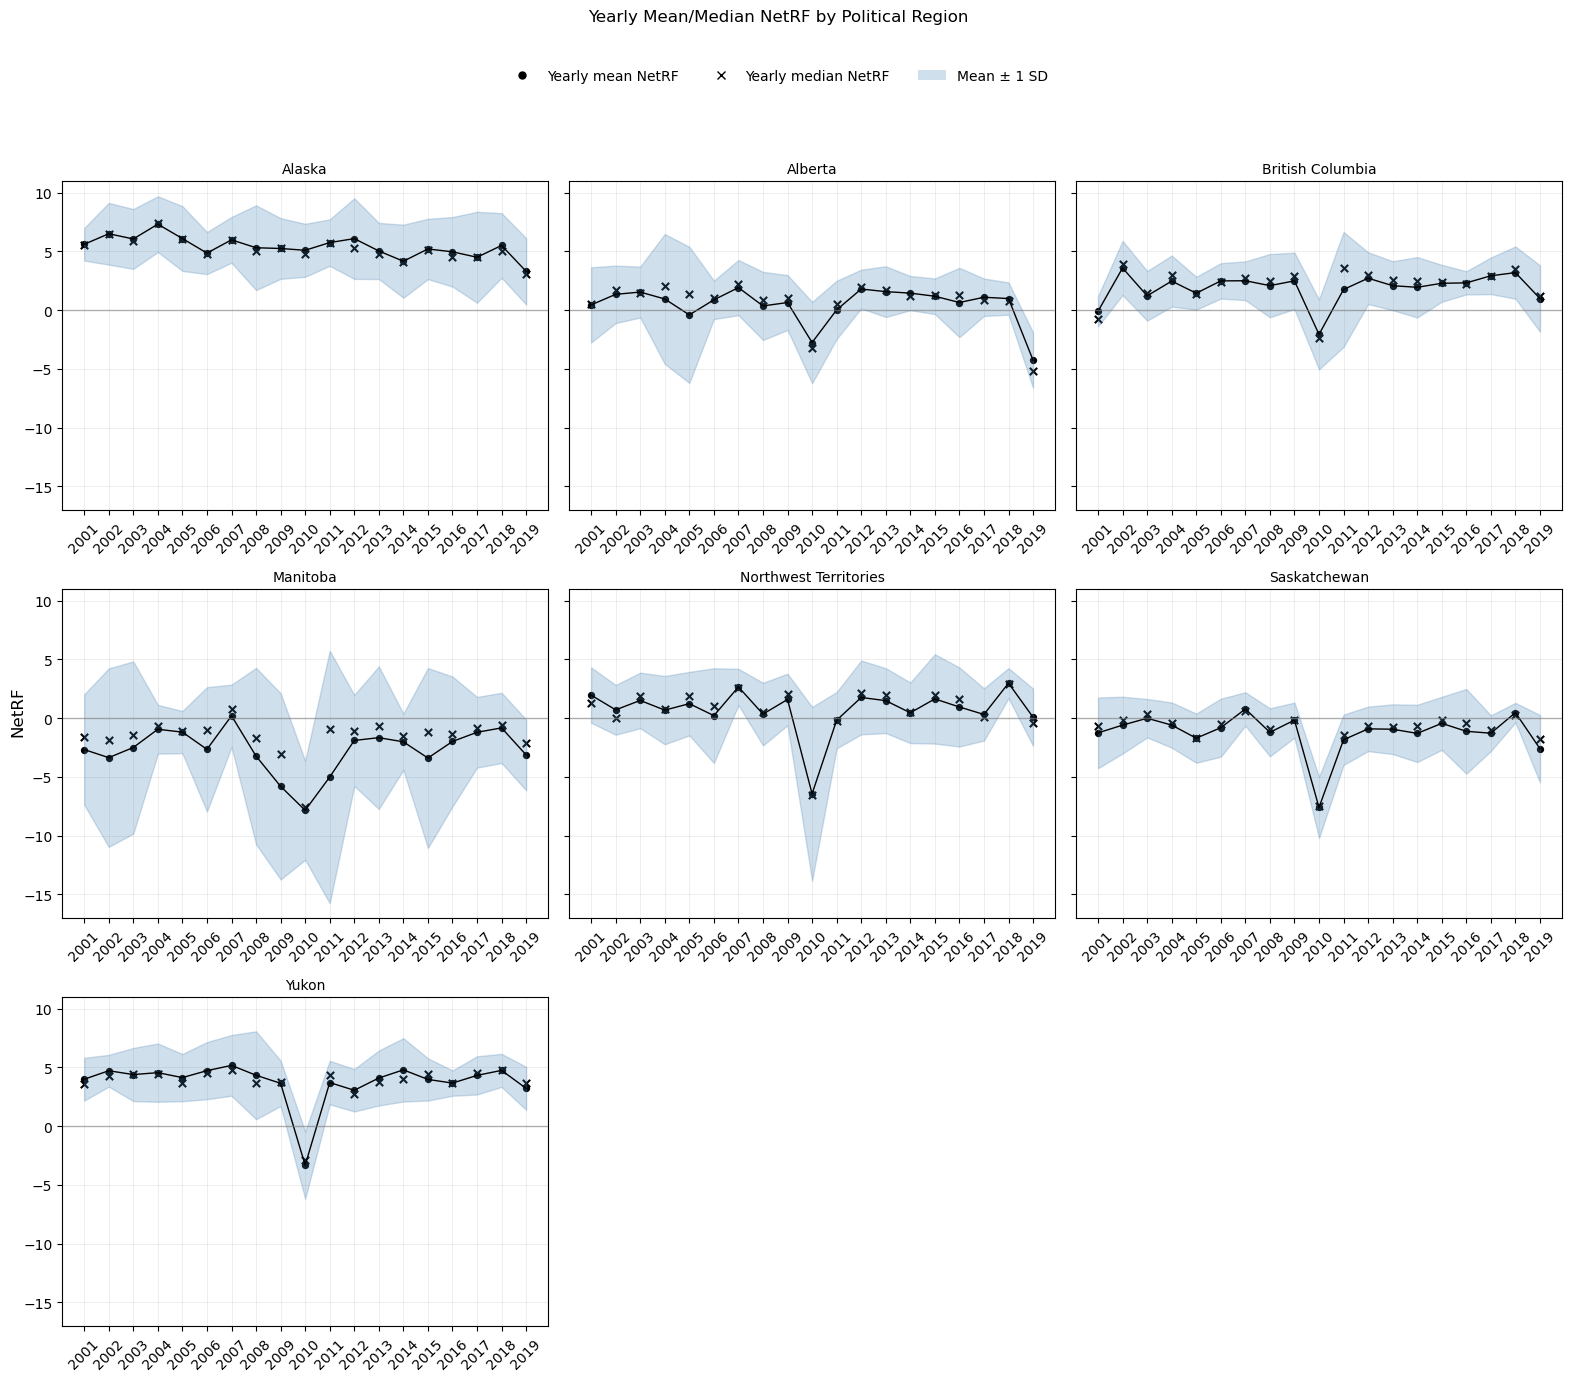

In [40]:
regions = sorted(
    r for r in df_filter["ctry"].dropna().unique()
)

n_cols = 3
n_rows = int(np.ceil(len(regions) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    region_yearly = (
        df_filter.loc[df_filter["ctry"] == region]
        .dropna(subset=["FIREYEAR", "NetRF"])
        .groupby("FIREYEAR", as_index=False)["NetRF"]
        .agg(mean="mean", median="median", std="std")
        .sort_values("FIREYEAR")
    )

    region_yearly["std"] = region_yearly["std"].fillna(0)

    ax.set_axisbelow(True)
    ax.grid(axis='both', linestyle='-', linewidth=0.6, alpha=0.25)
    ax.scatter(region_yearly["FIREYEAR"], region_yearly["mean"], color="black", s=18)
    ax.plot(region_yearly["FIREYEAR"], region_yearly["mean"], color="black", linewidth=1)
    ax.scatter(
        region_yearly["FIREYEAR"],
        region_yearly["median"],
        color="black",
        marker="x",
        s=28,
    )
    ax.fill_between(
        region_yearly["FIREYEAR"],
        region_yearly["mean"] - region_yearly["std"],
        region_yearly["mean"] + region_yearly["std"],
        color="steelblue",
        alpha=0.25,
    )

    ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_title(region, fontsize=10)
    ax.tick_params(axis='x', labelbottom=True, rotation=45)

for ax in axes[len(regions):]:
    ax.set_visible(False)

handles = [
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=5, label="Yearly mean NetRF"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=6, label="Yearly median NetRF"),
    Patch(facecolor="steelblue", alpha=0.25, label="Mean ± 1 SD"),
]

fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=3, frameon=False)

fig.supylabel("NetRF")
fig.suptitle("Yearly Mean/Median NetRF by Political Region", y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

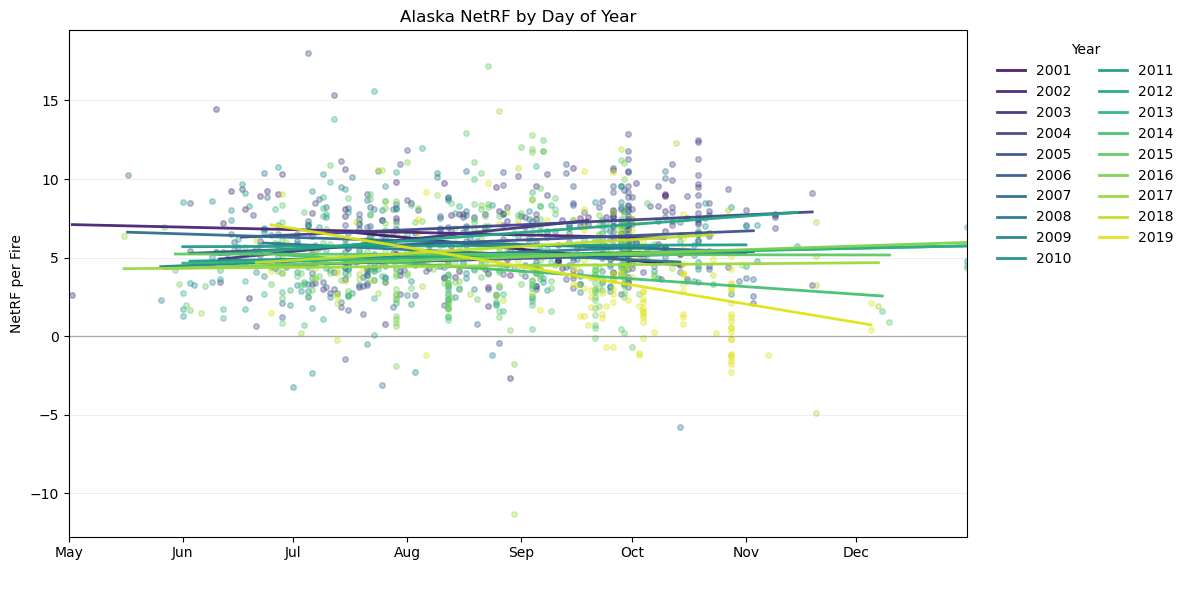

In [7]:
# Alaska only: all NetRF observations by day-of-year, with a trendline for each year.
ak_day_df = df_filter[df_filter["ctry"] == "Alaska"].copy()

year_col = "FIREYEAR" if "FIREYEAR" in ak_day_df.columns else "YEAR"
ak_day_df[year_col] = pd.to_numeric(ak_day_df[year_col], errors="coerce")

rep_dates = pd.to_datetime(ak_day_df["REP_DATE"], errors="coerce")
fpout_dates = pd.to_datetime(ak_day_df["FPOUTDATE"], errors="coerce")
best_dates_ak = rep_dates.fillna(fpout_dates)

existing_month = pd.to_numeric(ak_day_df["MONTH"], errors="coerce").replace(0, pd.NA)
existing_day = pd.to_numeric(ak_day_df["DAY"], errors="coerce").replace(0, pd.NA)

day_month = pd.to_numeric(best_dates_ak.dt.month.fillna(existing_month), errors="coerce")
day_day = pd.to_numeric(best_dates_ak.dt.day.fillna(existing_day), errors="coerce")

ak_day_df["month_day"] = pd.to_datetime(
    {
        "year": 2004,
        "month": day_month,
        "day": day_day,
    },
    errors="coerce",
)
ak_day_df["NetRF"] = pd.to_numeric(ak_day_df["NetRF"], errors="coerce")

ak_day_df = ak_day_df.dropna(subset=[year_col, "month_day", "NetRF"]).copy()
ak_day_df[year_col] = ak_day_df[year_col].astype(int)
ak_day_df["day_of_year"] = ak_day_df["month_day"].dt.dayofyear

years = sorted(ak_day_df[year_col].unique())
cmap = plt.get_cmap("viridis")
color_positions = np.linspace(0.05, 0.95, len(years))
year_colors = {y: cmap(pos) for y, pos in zip(years, color_positions)}

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

for year in years:
    s = ak_day_df[ak_day_df[year_col] == year].sort_values("month_day")

    # Plot every fire as a point at its calendar day.
    ax.scatter(
        s["month_day"],
        s["NetRF"],
        color=year_colors[year],
        s=16,
        alpha=0.35,
    )

    # Fit and draw a linear trendline for this year when possible.
    if s["day_of_year"].nunique() >= 2:
        slope, intercept = np.polyfit(s["day_of_year"], s["NetRF"], 1)
        x_num = np.linspace(s["day_of_year"].min(), s["day_of_year"].max(), 100)
        y_line = slope * x_num + intercept
        x_dates = pd.to_datetime("2004-01-01") + pd.to_timedelta(x_num - 1, unit="D")
        ax.plot(
            x_dates,
            y_line,
            color=year_colors[year],
            linewidth=2.0,
            alpha=0.95,
            label=str(year),
        )

ax.axhline(0, color="gray", linewidth=1, alpha=0.6)
ax.set_xlim(pd.Timestamp("2004-05-01"), pd.Timestamp("2004-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Alaska NetRF by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("NetRF per Fire")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [10]:
for year in years:
    s = ak_day_df[ak_day_df[year_col] == year].sort_values("month_day")
    print(s["month_day"].head())
    print(s["area_sqkm"].head())

2267   2004-07-15
2262   2004-08-07
2255   2004-08-15
2261   2004-10-14
2268   2004-10-14
Name: month_day, dtype: datetime64[ns]
2267      7.967433
2262      1.019712
2255     25.283894
2261      8.540845
2268    460.916131
Name: area_sqkm, dtype: float64
2190   2004-05-02
2244   2004-06-10
2232   2004-06-12
2231   2004-06-14
2225   2004-06-18
Name: month_day, dtype: datetime64[ns]
2190     0.046601
2244     0.682906
2232    51.436549
2231     0.281382
2225     1.485313
Name: area_sqkm, dtype: float64
2151   2004-06-11
2140   2004-06-27
2148   2004-06-28
2141   2004-07-06
2135   2004-07-09
Name: month_day, dtype: datetime64[ns]
2151     22.875369
2140      0.316130
2148     12.799053
2141    166.019212
2135      5.703700
Name: area_sqkm, dtype: float64
2097   2004-06-17
2101   2004-06-20
2120   2004-06-22
2117   2004-06-22
2119   2004-06-23
Name: month_day, dtype: datetime64[ns]
2097    1.083648
2101    5.764054
2120    1.445102
2117    7.087842
2119    0.948503
Name: area_sqkm, dtype:

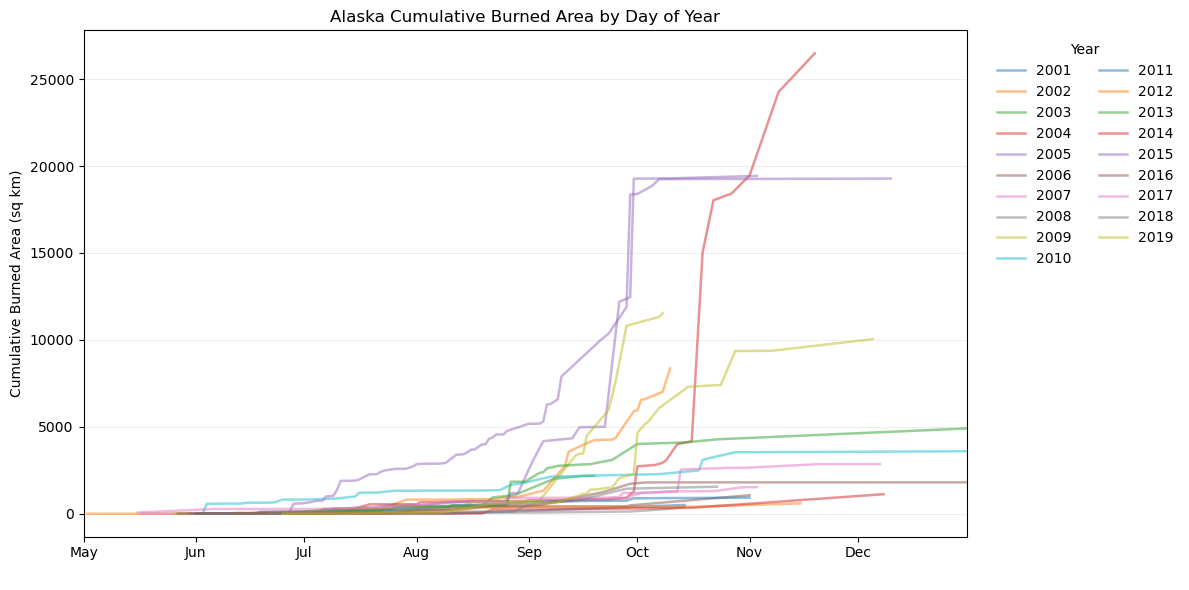

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)

for year in years:
    s = ak_day_df[ak_day_df[year_col] == year].sort_values("month_day").copy()
    s["area_sqkm"] = pd.to_numeric(s["area_sqkm"], errors="coerce")
    s = s.dropna(subset=["month_day", "area_sqkm"])

    # Sum area by calendar day, then accumulate through the season.
    daily = (
        s.groupby("month_day", as_index=False)["area_sqkm"]
        .sum()
        .sort_values("month_day")
    )
    daily["cum_area_sqkm"] = daily["area_sqkm"].cumsum()

    ax.plot(
        daily["month_day"],
        daily["cum_area_sqkm"],
        linewidth=1.8,
        alpha=0.5,
        label=str(year),
    )

ax.set_xlim(pd.Timestamp("2004-05-01"), pd.Timestamp("2004-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Alaska Cumulative Burned Area by Day of Year")
ax.set_xlabel(" ")
ax.set_ylabel("Cumulative Burned Area (sq km)")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
#could be worth making Max's original line plots by ecoregion and producing one set per decade or something. 
#Find some way to visualize the contributions of each RF input over time